# Structural QC_CV — кросс-плот и кросс-валидация для оценки качества структурных карт по данным скважин.

Валидация точности структурной карты против истинных глубин геологических маркеров в скважинах.

Ниже — полный план проекта Structural QC_CV, затем ноутбук, который показывает выполненные шаги 0–4 на данных скважин (движок `structural_qc_full.py`).

Для запуска нужны `structural_qc_full.py` рядом с ноутбуком и файл с данными скважин (в ноутбуке — `RAW`).

Автор: Алексей · геофизик → data scientist

## Описание проекта

Streamlit-инструмент, который сравнивает эталонный параметр PARAM_1 (Z_well) и сравниваемый PARAM_2 (Z_map) в одних и тех же точках — скважинах — и проверяет, насколько один параметр предсказывается по другому. Реализованы Шаги 0–4: загрузка и QC данных, базовый QC-кросс-плот с аппроксимациями, кросс-валидация по восьми схемам с автоматическим выбором лучшей, анализ по категориям и фильтрация скважин. Инструмент обобщён на любые пары числовых параметров.

## Описание данных

Входная таблица CSV/XLSX, в которой каждая строка — пара значений PARAM_1 и PARAM_2 в точке скважины (на горизонт). Обязательные колонки: well_id, X_coord, Y_coord, PARAM_1 (Zprm_well) и PARAM_2 (Zprm_map). Опциональные: horizon_id, tectonic_zone, reservoir_flag (тип коллектора), fluid_type (тип флюида) и любые другие числовые и категориальные колонки. В приложении есть демонстрационные файлы (выбор в сайдбаре) и пример структуры из трёх скважин: well_id, X_coord, Y_coord, Z_well, Z_map, horizon_id, tectonic_zone.

## Цели исследования

- Проверить согласованность структурной карты с данными скважин по глубинам горизонта (Z_map относительно Z_well).
- Оценить реальную, а не оптимистичную точность карты с помощью кросс-валидации по схемам, разбивающим данные по скважинам.
- Выявить систематические смещения (Bias, наклон регрессии) и зоны, горизонты или категории, где карта работает хуже.
- Проверить устойчивость результата к сокращению числа скважин, к отдельным наблюдениям и выбросам.

## Ход исследования

- Шаг 0 — загрузка данных, QC входных данных, статистика параметров, корреляционные матрицы Пирсона и Спирмена.
- Шаг 1 — базовый QC-кросс-плот, аппроксимации (17 типов), распределения, невязки, карта невязок, выбросы.
- Шаг 2 — кросс-валидация по восьми схемам, выбор лучшей по score = RMSE + RMSE_fold_std, детальный разбор лучшей схемы.
- Шаг 3 — диагностика по выбранной категориальной колонке.
- Шаг 4 — фильтрация скважин: ручная, случайная по проценту или выделением точек кликом.

## Ожидаемые результаты

- Сравнительная таблица ошибок (RMSE, MAE, Bias) по схемам CV и по фолдам с выбором лучшей схемы.
- Оценка смещения и тренда: Bias, наклон и intercept регрессии; тренд невязки от глубины как признак ошибки скоростной модели.
- Карта невязок и список выбросов по четырём правилам с указанием зон систематических ошибок.
- Метрики по категориям и оценка устойчивости результата при фильтрации скважин.
- Вывод о том, на каких участках и горизонтах карте можно доверять, а где её нужно пересмотреть.

План проекта. Версия сверена с реализацией (app_full.py, structural_qc_full.py, app_utils.py, translations_full.py) — обновлено, чтобы не противоречить коду.



## Постановка задачи

- Типичная задача валидации точности структурной поверхности (карты), построенной по данным МОГТ 2D/3D, против «истины» в скважинах — глубин геологических маркеров.
- Ключевой методологический риск: если скважины использовались при построении карты (калибровка скоростной модели, привязка ВСП, интерполяция/крайгинг с учётом скважинных данных), то проверка качества карты в этих же точках даёт завышенную, оптимистичную оценку — это классическая утечка данных (data leakage), только в геологической форме.
- Оценивается предиктивная модель (регрессия/аппроксимация), связывающая два параметра: эталонный PARAM_1 и сравниваемый PARAM_2. Для структурного QC: PARAM_1 = Z_well (истинная глубина горизонта), PARAM_2 = Z_map (глубина того же горизонта по структурной карте).
- Значения PARAM_2 на каждой итерации кросс-валидации фиксированы (не пересчитываются из сейсмики заново) — переобучается только модель связи «PARAM_2 → PARAM_1» при исключении скважины или группы скважин из обучающей выборки.

Инструмент реализован обобщённо и применим не только к паре «скважина ↔ карта», а к любой паре числовых параметров:

| Сценарий | PARAM_1 (Reference) / PARAM_2 (Compared) — примеры |
|---|---|
| скважина ↔ карта | Z_well / Z_map, T_well / T_map |
| скважина ↔ атрибут | Z_well / Amplitude, Phi_well / AVO_Gradient |
| карта ↔ карта | Z_map_v1 / Z_map_v2 (сравнение версий интерпретации) |
| атрибут ↔ атрибут | Amplitude / Sweetness (проверка мультиколлинеарности) |

Далее по тексту плана Z_well/Z_map используются как сквозной иллюстративный пример (структурный QC), но все шаги и формулы применимы к любой паре PARAM_1/PARAM_2.



## Формат данных

Минимальная структура входной таблицы (CSV/XLSX):

| Колонка в коде | Роль | Описание |
|---|---|---|
| well_id | обязательная | Идентификатор скважины |
| X_coord, Y_coord | обязательные | Координаты скважины |
| Zprm_well (= PARAM_1) | обязательная · Reference | Эталонный параметр — то, с чем сравниваем. Для структурного QC: Z_well (истинная глубина маркера). |
| Zprm_map (= PARAM_2) | обязательная · Compared | Сравниваемый параметр. Для структурного QC: Z_map (глубина по карте). |
| horizon_id | опциональная | Идентификатор горизонта — позволяет отфильтровать анализ по одному или нескольким горизонтам |
| tectonic_zone | опциональная | Тектоническая/геологическая зона — используется в Stratified by Zone CV и в Шаге 3 |
| любая другая колонка | опциональная | Любая дополнительная числовая колонка — доступна для корреляционного анализа (Шаг 0); любая категориальная — доступна для анализа по категориям (Шаг 3) |

- Единицы измерения PARAM_1 и PARAM_2 задаются пользователем при сопоставлении колонок (например, м, км, мс, м/с и т.п.) — используются только в подписях графиков и таблиц, не влияют на расчёт.
- При загрузке выполняется автоматическая очистка: приведение мусорных значений («NA», «NULL», «—», «?» и т.п.) к NaN, замена запятой на точку в числовых колонках, приведение типов, удаление строк с пропусками в обязательных колонках (с выводом отчёта, сколько строк удалено).
- Опциональные колонки reservoir_flag (тип коллектора) и fluid_type (тип флюида) используются как категориальные признаки для Шага 3 наравне с tectonic_zone.


## Метрики кросс-плота и обозначения

Обозначение: x = PARAM_2 (сравниваемое значение), y = PARAM_1 (эталонное значение).

Невязка Δ — определяется по-разному в двух местах кода, это важно:

- Базовый QC-кросс-плот (Шаг 1, BasicStats): Δ = y − x = PARAM_1 − PARAM_2. Для структурного QC: Δ = Z_well − Z_map. Положительная Δ ⇒ Z_well > Z_map (карта занижает глубину); отрицательная ⇒ карта завышает глубину.
- Аппроксимации и кросс-валидация (Шаги 1–3, FitStats / fold_metrics): Δ = Predicted − Actual, то есть предсказание модели минус фактическое PARAM_1 — обратный знак по сравнению с базовым QC-кросс-плотом.

Таблица ниже — общая форма метрик через Δ; какое именно Δ подставляется, зависит от раздела (см. выше). Δ̄ — среднее невязки (= Bias).

| Метрика | Формула |
|---|---|
| R² (коэффициент детерминации / квадрат корреляции) | $R^2_{lin} = r^2$ (Пирсон, лин. связь) &nbsp;·&nbsp; $R^2_{fit} = 1 - \dfrac{\sum(\Delta)^2}{\sum(y-\bar y)^2}$ (любая форма кривой) |
| RMSE (среднеквадратичная ошибка) | $\sqrt{\dfrac{1}{N}\sum (\Delta)^2}$ |
| MSE (среднеквадратичное отклонение) | $\dfrac{1}{N}\sum (\Delta)^2$ |
| MAE (абсолютная погрешность) | $\dfrac{1}{N}\sum \lvert \Delta \rvert$ |
| Bias (систематическое смещение) | $\dfrac{1}{N}\sum (\Delta)$ |
| Std (стандартное отклонение невязок) | $\sqrt{\dfrac{1}{N-1}\sum(\Delta_i-\bar\Delta)^2}$ |
| Variance (дисперсия невязок) | $\dfrac{1}{N-1}\sum(\Delta_i-\bar\Delta)^2$ |
| MAPE, % (ошибка в процентах) | $\dfrac{100}{N}\sum \dfrac{\lvert \Delta \rvert}{\max(\lvert y \rvert,\,10^{-9})}$ |
| P-value (значимость линейной корреляции) | $t = r\sqrt{\dfrac{N-2}{1-r^2}}$, &nbsp; $p = 2\left(1-F_{t,\,N-2}(\lvert t\rvert)\right)$ |
| Уравнение линейной регрессии | $y = a + bx$; наклон b и intercept a — из `linregress` |


P-value отвечает на вопрос: насколько вероятно получить настолько же сильную (или сильнее) линейную связь между PARAM_1 и PARAM_2 случайно, если на самом деле никакой связи нет (нулевая гипотеза H₀: истинный наклон регрессии b = 0). Чем меньше p-value, тем менее правдоподобно, что найденная зависимость — случайность; порогом значимости обычно считают p < 0.05. Считается только для базового QC-кросс-плота (Шаг 1), через scipy.stats.linregress.



__Статистика параметров (Шаг 0)__

Для PARAM_1 и PARAM_2 отдельно считается расширенная описательная статистика:

| Статистика | Формула / определение |
|---|---|
| Count | N — число непустых значений |
| μ (mean) | $\mu = \dfrac{1}{N}\sum x_i$ — среднее арифметическое |
| median | медиана — значение, делящее выборку пополам (50-й перцентиль) |
| mode | мода — наиболее часто встречающееся значение |
| σ (std) | $\sigma = \sqrt{\dfrac{1}{N-1}\sum(x_i-\mu)^2}$ |
| variance | $\sigma^2 = \dfrac{1}{N-1}\sum(x_i-\mu)^2$ |
| CV, % | $\dfrac{\sigma}{\mu}\times 100\%$ — коэффициент вариации (разброс относительно среднего) |
| min | минимальное значение |
| Q05 | 5-й перцентиль |
| Q25 | 25-й перцентиль (первый квартиль) |
| Q75 | 75-й перцентиль (третий квартиль) |
| Q95 | 95-й перцентиль |
| max | максимальное значение |
| range | $\max - \min$ |
| IQR | $Q75 - Q25$ — межквартильный размах |
| IQR lower bound | $Q25 - 1.5 \cdot IQR$ — нижняя граница для правила IQR |
| IQR upper bound | $Q75 + 1.5 \cdot IQR$ — верхняя граница для правила IQR |

В проекте два разных R² — разведены по названию, чтобы не путать. R²_lin (BasicStats.r2, Шаг 1, базовый QC-кросс-плот) = квадрат коэффициента корреляции Пирсона (scipy.stats.linregress) — корректен только как мера силы линейной связи. R²_fit (FitStats.r2, все 17 типов аппроксимации, Шаги 1–3) = sklearn.metrics.r2_score = 1 − SS_res/SS_tot — честная доля объяснённой дисперсии, корректна для кривой любой формы. Для линейной OLS оба совпадают численно, для остальных 16 типов — нет. Сравнивать R²_lin и R²_fit напрямую нельзя — это разные метрики, а не одна и та же величина, посчитанная дважды.

Коэффициенты линейной регрессии (наклон / intercept) показывают систематический тренд — например, «карта занижает глубину с ростом глубины» (b < 1) — типичный признак ошибки скоростной модели.



## Типы линий аппроксимации

На кросс-плоте, помимо базовой линейной регрессии, доступен выбор из 17 вариантов аппроксимации (10 полиномов 1–10 степени + 7 прочих методов):

| Метод | Общий вид уравнения | Когда полезен |
|---|---|---|
| Linear | $y = a + bx$ | Базовая линейная связь |
| Quadratic | $y = a + bx + cx^2$ | Связь с одним изгибом |
| Cubic | $y = a + bx + cx^2 + dx^3$ | Связь с точкой перегиба |
| Polynomial Degree 4–10 | $y = a_0 + a_1x + \dots + a_nx^n$ | Более сложная, но реже оправданная форма связи |
| Power Law | $y = a x^b$ &nbsp;($x,y>0$) | Степенная зависимость |
| Exponential | $y = a e^{bx}$ &nbsp;($y>0$) | Экспоненциальный рост/спад |
| Logarithmic | $y = a + b\ln x$ &nbsp;($x>0$) | Насыщение/замедление роста |
| Robust (Huber) | $y = a + bx$; коэффициенты минимизируют функцию потерь Хьюбера | Линейная связь, устойчивая к выбросам |
| Theil-Sen | $y = a + bx$; $b = \mathrm{median}\left(\dfrac{y_j-y_i}{x_j-x_i}\right)$ | Линейная связь, устойчивая к выбросам |
| RANSAC | $y = a + bx$; подбор по максимальному числу inlier-точек | Линейная связь при сильных выбросах/аномалиях |
| LOWESS | без единой формулы — локальная регрессия в скользящем окне | Повторяет форму облака точек без предположений о форме связи |
| Quantile Regression (τ=0.1/0.5/0.9) | $y = a_\tau + b_\tau x$ | Три линии для нижней/средней/верхней границы разброса |


- Huber, Theil-Sen, RANSAC — не новые формы кривой, а альтернативные способы оценки коэффициентов той же линейной модели, устойчивые к выбросам. Уравнение по-прежнему y = a + b·x, но a и b посчитаны иначе, чем в обычном МНК (OLS).
- LOWESS — не даёт единого уравнения: локальная модель, результат — кривая (набор предсказаний в каждой точке), а не формула с фиксированными коэффициентами. В реализации используется statsmodels lowess с frac = 0.3; значения в точках x получаются линейной интерполяцией кривой.
- Квантильная регрессия — даёт разные a_q, b_q для τ = 0.1 / 0.5 / 0.9; на графике — веер из трёх линий. Метрики считаются отдельно для каждой τ (compute_quantile_stats, оценка через statsmodels QuantReg): на графике аппроксимаций и в таблице метрик выводятся строки для τ = 0.1, 0.5 и 0.9. Для τ = 0.1 и 0.9 R²_fit может быть отрицательным — такие кривые оцениваются по Equation и Bias, а не по R². В общей таблице аппроксимаций (compute_fit_stats) учитывается только τ = 0.5.

Для степенной и логарифмической аппроксимации область определения ограничена (x > 0, и для степенной также y > 0); значения вне домена не участвуют в подгонке коэффициентов, а при отрисовке кривой заменяются на NaN вместо падения графика.

Метрики кривых аппроксимации (R²_fit, RMSE, MSE, MAE, Bias, Std, Variance, MAPE %, уравнение) считаются по невязке Predicted − Actual = model(x) − y, то есть между предсказанием модели и фактическим эталонным значением PARAM_1 — отдельно от метрик базового QC-кросс-плота (Residual = y − x, см. выше).


## Типы кросс-валидации (от худшего к лучшему)

| Метод | Суть | Когда применять |
|---|---|---|
| Random K-Fold | `sklearn.KFold(shuffle=True)`: скважины случайно перемешиваются и делятся на k равных частей (если заданное k превышает число точек n, оно автоматически уменьшается до n); каждая часть по очереди становится тестом, обучение — на остальных частях | ⚠️ Не для пространственных данных — даёт завышенную точность |
| Leave-One-Well-Out (LOWO) | `LeaveOneGroupOut` по `well_id`: поочерёдно вся скважина целиком (все её строки/горизонты) исключается из обучения и становится единственным тестом — так проверяется каждая скважина по разу | Стандарт при малом числе скважин (<20–30) |
| Block CV | Площадь делится регулярной сеткой grid_n×grid_n по X_coord/Y_coord; весь блок по очереди становится тестом, обучение — на скважинах вне блока (блок пропускается, если в нём <3 обучающих скважин) | Равномерная сетка скважин |
| Buffered CV | Как Block CV, но дополнительно из обучения убираются скважины, чьё минимальное расстояние до ближайшей тестовой точки блока ≤ buffer | Снижает утечку через границу блока |
| Leave-P-Out | На каждом из repeats повторов случайно (без возврата) выбирается p_percent% скважин — тест, обучение — на остальных; итоговый прогноз скважины — среднее по всем повторам, где она попадала в тест | Оценка разброса устойчивости при разном случайном составе теста |
| Spatial Leave-P-Out | На каждом из repeats повторов случайно выбирается скважина-центр; все скважины в радиусе ≤ radius от неё — тест, остальные — train; прогноз усредняется по повторам так же, как в Leave-P-Out | Ближе всего к реальному прогнозу новой необуренной площади |
| Stratified by Zone | `LeaveOneGroupOut` по `tectonic_zone`: поочерёдно вся тектоническая зона целиком становится тестом, обучение — на скважинах из остальных зон (нужно ≥2 уникальные зоны) | Проверка, переносится ли модель на новую зону |
| Distance-based exclusion CV | Для каждой скважины i по очереди: из обучения исключаются все скважины на расстоянии ≤ range_corr от неё (range_corr = медиана попарных расстояний между скважинами × variogram_factor), тест — только скважина i | Самая строгая проверка на пространственную утечку — по сути LOWO с буфером |


Как устроена Distance-based exclusion CV. Схема не выполняет полноценную подгонку модели вариограммы (nugget/sill/range) — радиус пространственной корреляции оценивается упрощённо, как медианное попарное расстояние между скважинами (estimate_variogram_range), масштабируемое множителем variogram_factor. Для тестовой скважины из обучения исключаются все точки ближе этого радиуса. Переименование в Distance-based exclusion CV точнее отражает, что метод делает на самом деле — это практичная эвристика на расстояниях, а не геостатистическая вариограмма.

__Автоматический подбор рекомендуемых параметров CV__

Реализован в сайдбаре на основе числа скважин (n_wells) и медианного расстояния между ними (median_dist):

- k для Random K-Fold: 5 при n<20; 7 при n<50; 10 при n<150; иначе 12.
- Сетка N×N для Block/Buffered CV: 5×5 при median_dist<300 м; 4×4 при <600 м; 3×3 при <1000 м; иначе 2×2.
- Buffer (Buffered CV): 0.5 × median_dist.
- Число повторов (cv_repeats) для Leave-P-Out / Spatial Leave-P-Out: 100 при n<30; 50 при n<100; 30 при n<300; иначе 20.
- Радиус пространственного исключения (Spatial Leave-P-Out): ≈ median_dist.
- Множитель радиуса корреляции (Distance-based exclusion CV factor, variogram_factor в коде): 0.5 — мягкая фильтрация; 1.0 — рекомендуемое значение; 1.5 — строгая; 2.0–3.0 — очень строгая, почти независимые скважины.

Все рекомендованные значения доступны для ручной корректировки через слайдеры в сайдбаре.

__Выбор лучшей схемы CV__


После расчёта всех схем автоматически определяется схема с наилучшим сочетанием точности и устойчивости:

score = RMSE + RMSE_fold_std  →  min

Схема с минимальным score считается лучшей; для неё повторяется часть Шага 1 (кросс-плот Predicted vs Actual, аппроксимации, распределения, карта невязок, анализ выбросов).


# Ход исследований

## Загрузка данных

### QC входных данных

- Полные дубликаты строк
- Дубликаты well_id (для нескольких горизонтов на одну скважину это ожидаемо; реальное дублирование — только при совпадении well_id и horizon_id)
- Совпадающие координаты скважин (X_coord, Y_coord)
- Пропуски по колонкам
- Строки, удалённые при очистке (с превью первых 20 строк)

### Типы данных по колонкам

- Для каждой колонки: тип (Numeric / Date & Time / Boolean / String), pandas dtype, число непустых/пустых значений, число уникальных значений.
- Отдельно — список уникальных значений для каждой категориальной колонки (до 20 значений с указанием общего числа).

### Статистика параметров PARAM_1, PARAM_2

- Полный набор статистик и их формулы — см. раздел «Статистика параметров (Шаг 0)» ниже.

### Корреляционный анализ выбранных параметров

- Две матрицы корреляции для любого набора числовых колонок: Пирсона (только линейная связь) и Спирмена (любая монотонная связь — экспонента, логарифм, степенная) (не только PARAM_1/PARAM_2 — пользователь выбирает набор).
- Pairplot: Seaborn (статический, с KDE/histogram на диагонали) или Plotly (интерактивный scatter-matrix).
- Для Pairplot рекомендуется не более 6 параметров (предупреждение в интерфейсе), для блока корреляционного анализа — не более 10. KDE и гистограммы на диагонали доступны только в Seaborn; Plotly даёт интерактивность и hover.
- Статистика по каждому выбранному параметру — в отдельных раскрывающихся блоках.

---

## Шаг 1: Базовый QC-кросс-плот 

### Классический QC cross-plot

- Ось X: PARAM_2 (сравниваемое значение).
- Ось Y: PARAM_1 (эталонное значение).
- Диагональ: линия идеального совпадения Y = X.
- Линия линейной регрессии (OLS, степень 1).

Метрики раздела «Метрики кросс-плота и обозначения» выше (R²_lin, RMSE, MSE, MAE, Bias, Std, Variance, MAPE %, P-value, уравнение регрессии).

### Кросс-плот с кривыми аппроксимации

- На тот же кросс-плот накладываются выбранные пользователем типы аппроксимации (из 17, см. раздел выше).
- Для каждой выбранной кривой — отдельная строка в сравнительной таблице метрик (R²_fit = sklearn r2_score, см. предупреждение про два R² выше).

### Распределения параметров PARAM_1 и PARAM_2

- Гистограммы с KDE, линиями Mean/Median/±3σ (опционально).
- Boxplot с линиями Mean/Median.
- Настраиваемое число бинов и тип нормализации гистограммы (none/density/probability/percent).

### Распределение невязок Δ = PARAM_1 − PARAM_2

- График невязки от PARAM_1 — ищем тренд (признак ошибки скоростной модели), а не просто разброс.
- Расширенная таблица статистик невязок: Count, μ, median, mode, σ, variance, CV %, RMSE, min, Q05/Q25/Q75/Q95, max, range, IQR (+ границы), μ±3σ.
- Гистограмма и boxplot невязок.
- Карта невязок в плане (X_coord, Y_coord, цвет — величина невязки) — показывает зоны систематического смещения (качество сейсмики, тектонические осложнения, латеральные изменения скоростей), а не просто общую статистику.

### Анализ выбросов по невязкам

Выбросы оцениваются четырьмя независимыми методами одновременно:

- Sigma rule: |Residual| > σ_thr·σ (порог σ_thr настраивается, по умолчанию 2.0).
- IQR rule: за пределами [Q1 − 1.5·IQR, Q3 + 1.5·IQR].
- Modified Z-score rule: |0.6745·(x − median)/MAD| > 3.5.
- Percentile rule: за пределами [Q05, Q95].

---

## Шаг 2: Кросс-валидация

Запускаются все схемы CV из раздела «Типы кросс-валидации» (Stratified by Zone пропускается, если в данных нет колонки tectonic_zone с ≥2 уникальными значениями).

### Для каждой схемы CV

- Cross-plot Predicted vs Actual.
- Метрики: R²_fit, RMSE, MSE, MAE, Bias, Std, Variance, MAPE %, P-value, уравнение регрессии.
- Статистика по фолдам: rmse_fold_mean, median, min, max, std, range.

### Сравнение схем

- Сводная таблица всех схем с метриками по фолдам.
- Bar chart RMSE по схемам CV.
- Автоматический выбор лучшей схемы по score = RMSE + RMSE_fold_std (см. раздел выше).

### Детальный разбор лучшей схемы (повтор части Шага 1)

- Cross-plot Predicted vs Actual для лучшей модели + кривые аппроксимации.
- Метрики cross-plot и сравнение аппроксимаций.
- Распределение CV-невязок (Residual = PARAM_1 − Predicted): график от PARAM_1, таблица статистик, гистограмма, boxplot.
- Анализ выбросов CV-невязок — теми же 4 методами, что и в Шаге 1.

Важно: при исключении скважины из фолда пересчитываются коэффициенты модели; значения PARAM_2 остаются неизменными — фиксированные входные данные, извлечённые один раз (например, из структурной карты).

---

## Шаг 3: Диагностика по категориям

Работает для любой категориальной колонки датасета (не только tectonic_zone) — пользователь выбирает, по какой колонке анализировать.

- Круговая и столбчатая диаграммы количества скважин по категориям.
- Статистика PARAM_1 и PARAM_2 по каждой категории (в раскрывающихся блоках).
- Boxplot распределения PARAM_1 и PARAM_2 по категориям.
- Общий кросс-плот по всем категориям сразу (с индивидуальными цветами точек/линий на категорию) + отдельно по выбранному подмножеству категорий.
- Кросс-плот и аппроксимации отдельно для каждой категории.
- Сравнительная таблица метрик аппроксимаций по категориям.

---

## Шаг 4: Фильтрация скважин

Реализовано (не только запланировано). Четыре режима:

- Без фильтра.
- Ручное исключение: мультиселект конкретных well_id.
- Случайное исключение (%): слайдер 0–95%, кнопка «Новый набор» для пересэмплирования (фиксированный seed сохраняется в session_state до нажатия кнопки).
- Выделение кликом по точкам на cross-plot: клик по точке (Shift+клик — несколько), рамка (Box) или лассо (Lasso); режимы переключаются иконками в правом верхнем углу графика. Выбранные точки фиксируются кнопкой «Применить исключение», «Сбросить всё» очищает выбор. В сводке показывается строка «Исключено кликом».

После фильтрации пересчитываются: QC cross-plot, аппроксимации, полная таблица метрик, сравнение «до / после фильтрации» (n скважин, R²_lin и R²_fit для выбранных кривых, RMSE, MSE, MAE, Bias, Std, Variance, MAPE %).

Это позволяет оценивать устойчивость модели к сокращению числа скважин и влияние отдельных наблюдений/их групп на качество зависимости.

---

## Важные нюансы для сейсмики

__Пространственная зависимость__

- Если скважины кластеризованы (например, куст на одной структуре), обычный LOWO даёт слишком оптимистичную оценку — соседняя скважина «утекает» информацию.
- Лучше — Block/Buffered/Spatial CV: исключать не одну скважину, а группу скважин в радиусе корреляции (аналог GroupKFold по пространственным кластерам).

__Размер выборки__

- Скважин мало (<15–20): LOWO практически безальтернативен.
- Скважин больше 30–50: можно k-fold (5–10 фолдов), но желательно с равномерным пространственным покрытием в каждом фолде, иначе один фолд может остаться без скважин на краю площади (для этого в проекте есть Block/Buffered CV).

Важно: разбивать по скважинам, а не по отдельным точкам одной скважины — иначе модель «подглядывает» в соседние точки того же профиля/куста.

__Известные ограничения и статус реализации__

- R²_lin и R²_fit — два разных по смыслу R² в разных частях таблиц метрик, разведены по названию — см. предупреждение в разделе «Метрики кросс-плота и обозначения».
- Distance-based exclusion CV (ранее Variogram-Aware CV) — упрощённая эвристика на расстояниях, не полноценная geostatistics-вариограмма — см. пояснение в разделе «Типы кросс-валидации».
- Исправлено: степенная и логарифмическая аппроксимации могли давать NaN/падать при отрисовке кривой на участке x ≤ 0 — добавлено ограничение домена (x_line_safe) как в структурном QC-движке, так и в коде отрисовки Streamlit.
- Добавлено кэширование (@st.cache_data) для sq.run_all_cv — кросс-валидация (включая Leave-P-Out/Spatial Leave-P-Out с десятками повторов) больше не пересчитывается при каждом взаимодействии с сайдбаром (например, смене цвета точек), а только при изменении данных или параметров CV.
- Реализован двуязычный интерфейс RU/EN (переключатель Language в сайдбаре; тексты в translations_full, примеры в ui_examples_full_ru и ui_examples_full_en). Планируется: разбиение app_full.py (~3500 строк) на модули (sidebar / step1–step4 / plotting).

---

## Практическая схема пайплайна

- Сбор данных: well_id, X_coord, Y_coord, PARAM_1, PARAM_2, horizon_id, tectonic_zone (опционально).
- Базовый анализ: глобальные RMSE/MAE/Bias, общий cross-plot, карта невязок (Шаг 0–1).
- K-fold CV по скважинам: разбить на k фолдов, перестроить модель без тестового фолда, посчитать ошибки, свести в таблицу.
- LOWO / Block / Buffered / Spatial Leave-P-Out / Distance-based exclusion / Stratified by Zone CV — полный набор схем для оценки устойчивости (Шаг 2).
- Диагностика по категориям — выявление зон систематических ошибок (Шаг 3).
- Фильтрация и стресс-тест выборки — оценка устойчивости к сокращению числа скважин (Шаг 4).
- Интерпретация: сравнить ошибки разных схем CV, выделить зоны/горизонты систематических ошибок, использовать для доработки глубинного преобразования, скоростной модели, интерпретации разломов.

---

<a class="anchor" id="contents"></a>
# Содержание:<a class="anchor" id="ch8"></a>

* [Загрузка данных](#ch8_1)
* [Шаг 1: Базовый QC-кросс-плот](#ch8_2)
* [Шаг 2: Кросс-валидация](#ch8_3)
* [Шаг 3: Диагностика по категориям](#ch8_4)
* [Шаг 4: Фильтрация скважин](#ch8_5)
* [Выводы](#ch8_6)

# Выполнение проекта

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import structural_qc_full as sq

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": "#E5E5E5",
    "font.size": 11,
})
RED, BLUE = "#C23A22", "#2F5FA8"

## __Загрузка данных__ <a class="anchor" id="ch8_1"></a>

Ожидаемый формат файла: `well_id, X, Y, Z_well, Z_map`, опционально `horizon_id`, `tectonic_zone`, `quality_flag`.

Движок работает с именами колонок `well_id, X_coord, Y_coord, Zprm_well, Zprm_map`, поэтому при загрузке колонки переименовываются. Очистка повторяет логику приложения: мусорные значения («NA», «NULL», «—», «?») → NaN, запятая → точка, удаление строк с пропусками в обязательных колонках.

In [2]:
RAW = r"data/structural_wells_100_linear.csv"
REQUIRED = ["well_id", "X_coord", "Y_coord", "Zprm_well", "Zprm_map"]

raw = pd.read_csv(RAW, na_values=["NA", "NULL", "—", "?", ""], dtype=str)
raw.columns = raw.columns.str.strip()
df = raw.rename(columns={"X": "X_coord", "Y": "Y_coord",
                         "Z_well": "Zprm_well", "Z_map": "Zprm_map"})

for c in ["X_coord", "Y_coord", "Zprm_well", "Zprm_map"]:
    df[c] = pd.to_numeric(df[c].str.replace(",", ".", regex=False), errors="coerce")
for c in [c for c in ["T_well", "T_map"] if c in df.columns]:
    df[c] = pd.to_numeric(df[c].str.replace(",", ".", regex=False), errors="coerce")

n_before = len(df)
df = df.dropna(subset=REQUIRED).reset_index(drop=True)
print(f"n = {len(df)} строк, удалено при очистке: {n_before - len(df)}")
df.head()

n = 200 строк, удалено при очистке: 0


,well_id,X_coord,Y_coord,Zprm_well,Zprm_map,horizon_id,tectonic_zone,well_category,reservoir_flag,fluid_type,T_well,T_map
0,W-001,7501.1,9671.5,2319.03,2304.07,Top_Reservoir,Central_Graben,production,non_reservoir,non_reservoir,1713.24,1791.03
1,W-001,7501.1,9671.5,2260.24,2241.90,Top_Seal,Central_Graben,production,non_reservoir,non_reservoir,1669.81,1742.84
2,W-002,10766.6,6577.6,2485.68,2463.86,Top_Reservoir,South_Block,production,reservoir,water,1768.15,1781.45
3,W-002,10766.6,6577.6,2449.96,2428.13,Top_Seal,South_Block,production,reservoir,water,1742.74,1757.54
4,W-003,9308.2,4282.2,2538.94,2555.91,Top_Reservoir,South_Block,production,reservoir,water,1866.42,1821.17


__QC входных данных и статистика (Шаг 0)__

In [3]:
print("Полных дублей строк:", df.duplicated().sum())
print("Строк с повторяющимся well_id:", df["well_id"].duplicated(keep=False).sum())
key = ["well_id"] + (["horizon_id"] if "horizon_id" in df.columns else [])
print("Реальных дублей (" + " + ".join(key) + "):", df.duplicated(subset=key).sum())
print("Уникальных скважин:", df["well_id"].nunique())

Полных дублей строк: 0
Строк с повторяющимся well_id: 200
Реальных дублей (well_id + horizon_id): 0
Уникальных скважин: 100


In [4]:
if "quality_flag" in df.columns:
    print(df["quality_flag"].value_counts(dropna=False))
df.groupby("tectonic_zone")["Zprm_well"].agg(["count", "mean", "std"]).round(1)

,count,mean,std
tectonic_zone,,,
Central_Graben,76,2394.3,68.5
North_Block,72,2296.7,71.5
South_Block,52,2470.5,60.0


In [5]:
rows = []
for c in df.columns:
    s = df[c]
    if pd.api.types.is_bool_dtype(s):
        t = "Boolean"
    elif pd.api.types.is_numeric_dtype(s):
        t = "Numeric"
    elif pd.api.types.is_datetime64_any_dtype(s):
        t = "Date & Time"
    else:
        t = "String"
    rows.append({"колонка": c, "тип": t, "dtype": str(s.dtype), "непустых": int(s.notna().sum()),
                 "пустых": int(s.isna().sum()), "уникальных": int(s.nunique())})
display(pd.DataFrame(rows))

for c in df.select_dtypes(exclude="number").columns:
    vals = df[c].dropna().unique()
    print(f"{c} — {len(vals)} значений: {list(vals[:20])}")

,колонка,тип,dtype,непустых,пустых,уникальных
0,well_id,String,object,200,0,100
1,X_coord,Numeric,float64,200,0,100
2,Y_coord,Numeric,float64,200,0,100
3,Zprm_well,Numeric,float64,200,0,200
4,Zprm_map,Numeric,float64,200,0,199
5,horizon_id,String,object,200,0,2
6,tectonic_zone,String,object,200,0,3
7,well_category,String,object,200,0,3
8,reservoir_flag,String,object,200,0,2
9,fluid_type,String,object,200,0,4


well_id — 100 значений: ['W-001', 'W-002', 'W-003', 'W-004', 'W-005', 'W-006', 'W-007', 'W-008', 'W-009', 'W-010', 'W-011', 'W-012', 'W-013', 'W-014', 'W-015', 'W-016', 'W-017', 'W-018', 'W-019', 'W-020']
horizon_id — 2 значений: ['Top_Reservoir', 'Top_Seal']
tectonic_zone — 3 значений: ['Central_Graben', 'South_Block', 'North_Block']
well_category — 3 значений: ['production', 'exploration', 'appraisal']
reservoir_flag — 2 значений: ['non_reservoir', 'reservoir']
fluid_type — 4 значений: ['non_reservoir', 'water', 'gas', 'oil']


In [6]:
def param_stats(s):
    s = pd.Series(s).dropna().astype(float)
    mu, sd = s.mean(), s.std(ddof=1)
    q05, q25, q50, q75, q95 = s.quantile([0.05, 0.25, 0.5, 0.75, 0.95])
    iqr = q75 - q25
    mode = s.round(2).mode()
    return {
        "Count": len(s), "μ (mean)": mu, "median": q50,
        "mode": mode.iloc[0] if len(mode) else np.nan,
        "σ (std)": sd, "variance": sd ** 2, "CV, %": sd / mu * 100,
        "min": s.min(), "Q05": q05, "Q25": q25, "Q75": q75, "Q95": q95, "max": s.max(),
        "range": s.max() - s.min(), "IQR": iqr,
        "IQR lower bound": q25 - 1.5 * iqr, "IQR upper bound": q75 + 1.5 * iqr,
    }

pd.DataFrame({"Z_well (PARAM_1)": param_stats(df["Zprm_well"]),
              "Z_map (PARAM_2)": param_stats(df["Zprm_map"])}).round(2)

,Z_well (PARAM_1),Z_map (PARAM_2)
Count,200.00,200.00
μ (mean),2379.01,2372.47
median,2383.47,2363.07
mode,2187.35,2361.29
σ (std),96.17,101.29
variance,9248.74,10259.88
"CV, %",4.04,4.27
min,2187.35,2176.58
Q05,2216.59,2214.66
Q25,2304.45,2285.76


In [7]:
corr_cols = ["Zprm_well", "Zprm_map", "X_coord", "Y_coord"]
print("Пирсон (только линейная связь):")
display(df[corr_cols].corr(method="pearson").round(2))
print("\nСпирмен (любая монотонная связь):")
display(df[corr_cols].corr(method="spearman").round(2))

Пирсон (только линейная связь):


,Zprm_well,Zprm_map,X_coord,Y_coord
Zprm_well,1.00,0.90,0.75,-0.41
Zprm_map,0.90,1.00,0.69,-0.36
X_coord,0.75,0.69,1.00,0.13
Y_coord,-0.41,-0.36,0.13,1.00



Спирмен (любая монотонная связь):


,Zprm_well,Zprm_map,X_coord,Y_coord
Zprm_well,1.00,0.90,0.73,-0.42
Zprm_map,0.90,1.00,0.68,-0.37
X_coord,0.73,0.68,1.00,0.13
Y_coord,-0.42,-0.37,0.13,1.00


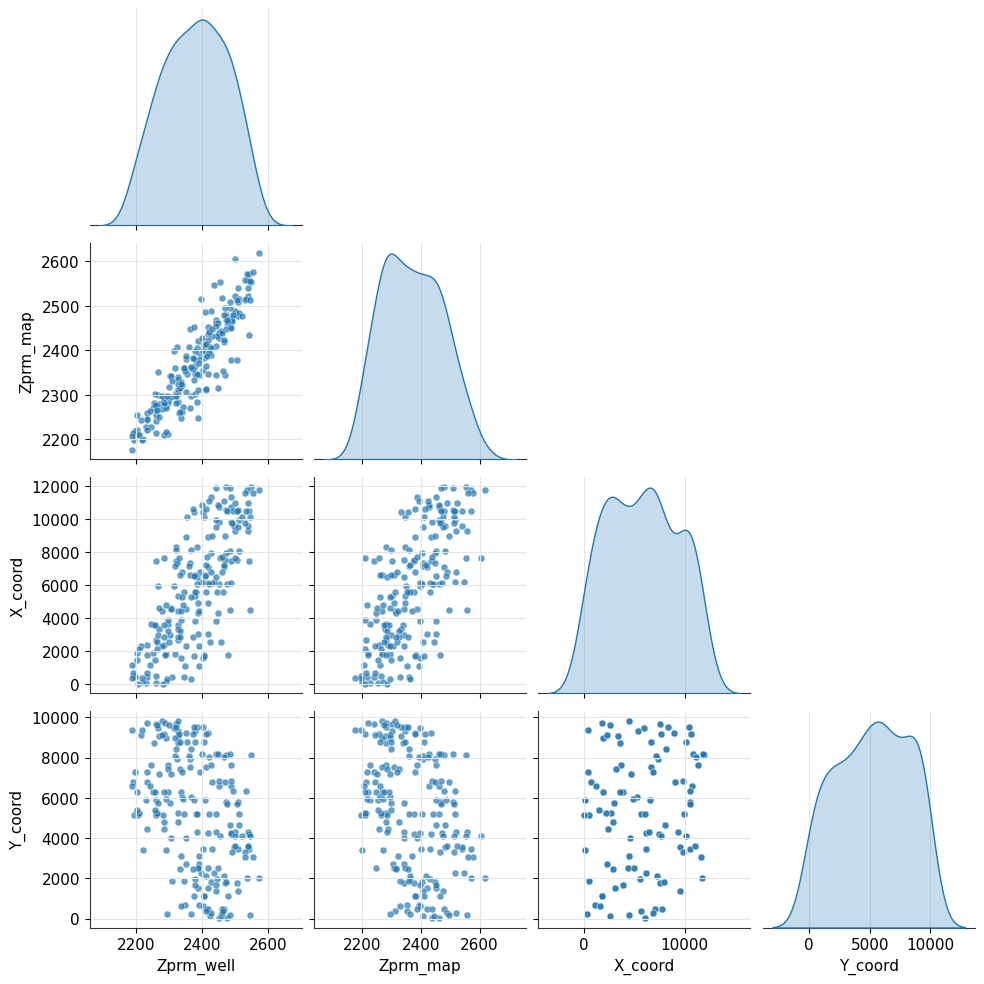

In [8]:
try:
    import seaborn as sns
    g = sns.pairplot(df[["Zprm_well", "Zprm_map", "X_coord", "Y_coord"]],
                     diag_kind="kde", corner=True, plot_kws={"s": 25, "alpha": .7})
    plt.show()
except ImportError:
    print("seaborn не установлен — pairplot пропущен (в приложении доступны Seaborn и Plotly)")

<div class="alert alert-info">
  <b> * <a href="#ch8">к содержанию</a> </b> 
</div>

---

## Шаг 1: __Базовый QC-кросс-плот__ <a class="anchor" id="ch8_2"></a> 

Z_well (эталон) против Z_map (сравниваемое значение). Невязка: `Δ = Z_well − Z_map`. Положительная Δ — карта занижает глубину, отрицательная — завышает.

In [9]:
basic = sq.basic_crossplot_stats(df)
print(f"R²_lin  = {basic.r2:.3f}")
print(f"slope   = {basic.slope:.3f}   intercept = {basic.intercept:+.2f} м")
print(f"p-value = {basic.p_value:.2e}")
print(f"RMSE    = {basic.rmse:.2f} м")
print(f"MAE     = {basic.mae:.2f} м")
print(f"Bias    = {basic.bias:+.2f} м")
print(f"Std     = {basic.std:.2f} м")
print(f"MAPE    = {basic.mape_pct:.2f} %")

R²_lin  = 0.810
slope   = 0.855   intercept = +351.61 м
p-value = 2.36e-73
RMSE    = 44.79 м
MAE     = 32.08 м
Bias    = +6.54 м
Std     = 44.42 м
MAPE    = 1.34 %


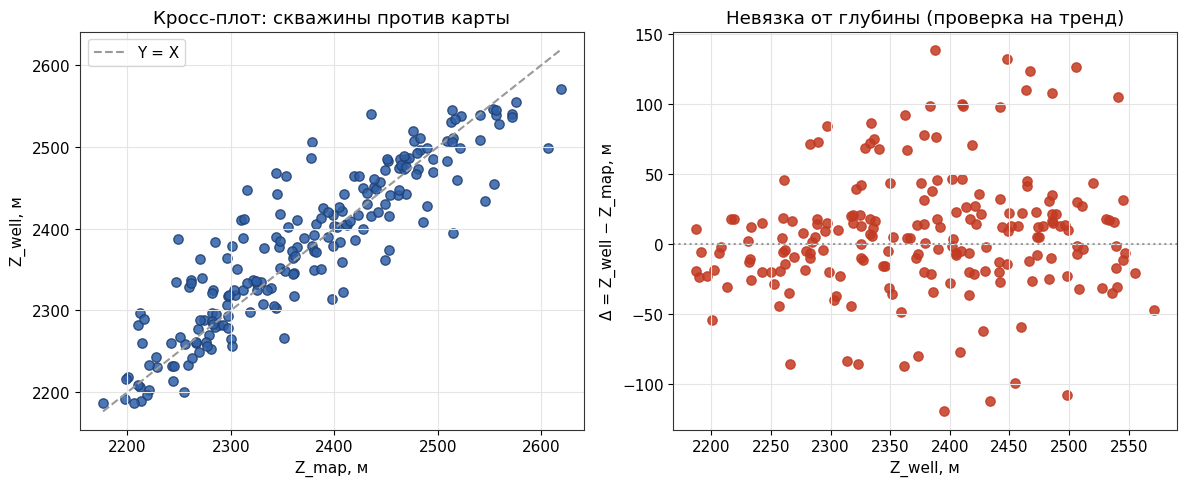

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lo = df[["Zprm_well", "Zprm_map"]].min().min()
hi = df[["Zprm_well", "Zprm_map"]].max().max()
axes[0].plot([lo, hi], [lo, hi], "--", color="#999", label="Y = X")
axes[0].scatter(df["Zprm_map"], df["Zprm_well"], c=BLUE, edgecolor="#1F3F70", s=45, alpha=.85)
axes[0].set_xlabel("Z_map, м"); axes[0].set_ylabel("Z_well, м")
axes[0].set_title("Кросс-плот: скважины против карты")
axes[0].legend()

axes[1].axhline(0, ls=":", color="#999")
axes[1].scatter(df["Zprm_well"], basic.residuals, c=RED, s=45, alpha=.85)
axes[1].set_xlabel("Z_well, м"); axes[1].set_ylabel("Δ = Z_well − Z_map, м")
axes[1].set_title("Невязка от глубины (проверка на тренд)")

plt.tight_layout()
plt.show()

**Наблюдение:** если невязка растёт с глубиной — это признак ошибки скоростной модели при глубинном преобразовании, а не случайного шума. Это стоит проверить отдельно от общего RMSE.

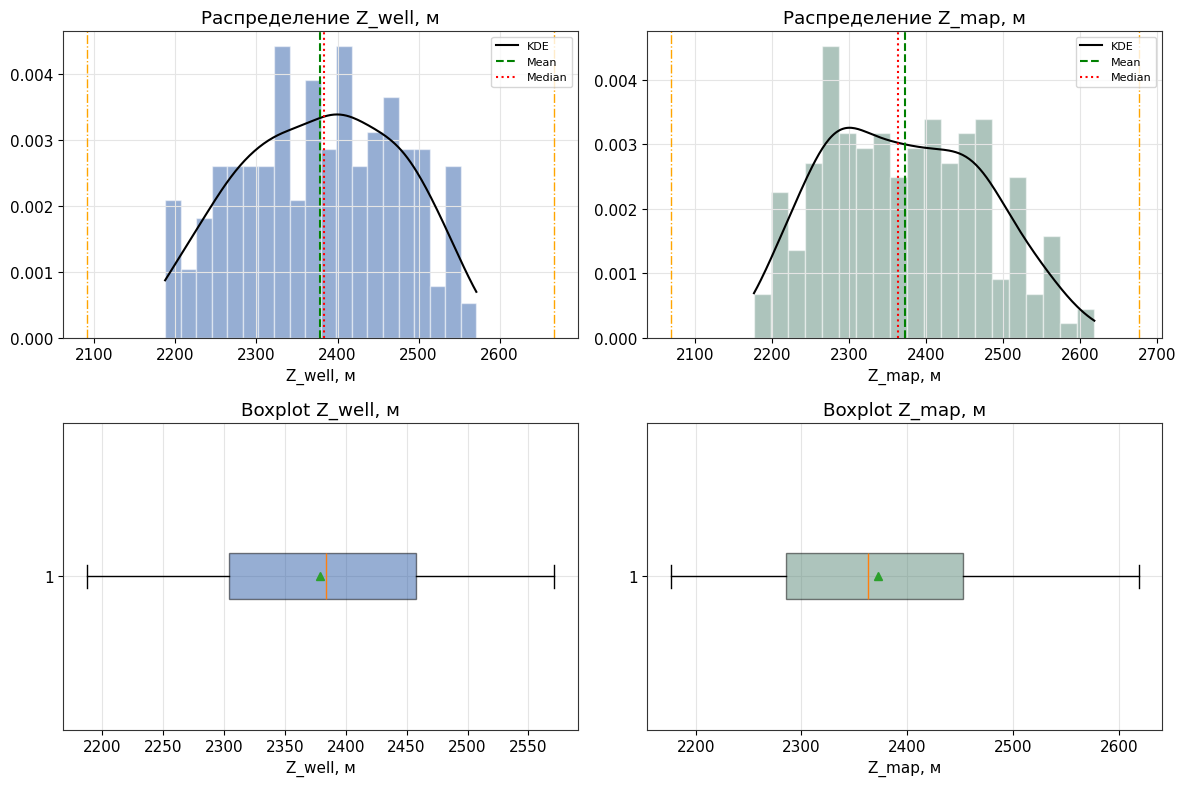

In [11]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for j, (col, label, colr) in enumerate([("Zprm_well", "Z_well, м", BLUE),
                                         ("Zprm_map", "Z_map, м", "#5C8A7A")]):
    s = df[col].to_numpy(float)
    ax = axes[0, j]
    ax.hist(s, bins=20, density=True, color=colr, alpha=.5, edgecolor="white")
    xs = np.linspace(s.min(), s.max(), 200)
    ax.plot(xs, gaussian_kde(s)(xs), color="black", label="KDE")
    m, md, sd = s.mean(), np.median(s), s.std(ddof=1)
    ax.axvline(m, color="green", ls="--", label="Mean")
    ax.axvline(md, color="red", ls=":", label="Median")
    for k in (-3, 3):
        ax.axvline(m + k * sd, color="orange", ls="-.", lw=1)
    ax.set_title(f"Распределение {label}"); ax.set_xlabel(label); ax.legend(fontsize=8)
    bp = axes[1, j].boxplot(s, vert=False, showmeans=True, patch_artist=True,
                            boxprops=dict(facecolor=colr, alpha=.5))
    axes[1, j].set_title(f"Boxplot {label}"); axes[1, j].set_xlabel(label)
plt.tight_layout(); plt.show()

__Аппроксимации и квантильная регрессия (Шаг 1)__

В приложении на кросс-плот накладываются 17 типов кривых. Здесь — сравнительная таблица для части из них. Метрики считаются по невязке `Predicted − Actual`.

In [12]:
x = df["Zprm_map"].to_numpy(float)
y = df["Zprm_well"].to_numpy(float)

approx_list = (["Linear", "Quadratic", "Cubic"]
               + [f"Polynomial Degree {n}" for n in range(4, 11)]
               + ["Power Law", "Exponential", "Logarithmic",
                  "Robust (Huber)", "Theil-Sen", "RANSAC", "LOWESS"])   # 17 типов

rows = []
for a in approx_list:
    s = sq.compute_fit_stats(x, y, a)
    rows.append({"Аппроксимация": a, "R²_fit": s.r2, "RMSE": s.rmse,
                 "MAE": s.mae, "Bias": s.bias, "Уравнение": s.equation})
pd.DataFrame(rows).round(3)

E:\projects\My_project\ML_Geophysics\structural_qc_project\structural_qc_full.py:217: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, degree)
E:\projects\My_project\ML_Geophysics\structural_qc_project\structural_qc_full.py:217: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x, y, degree)


,Аппроксимация,R²_fit,RMSE,MAE,Bias,Уравнение
0,Linear,0.810,41.804,31.825,-0.000,y = 0.85455·x + 351.61268
1,Quadratic,0.817,41.013,31.272,-0.000,y = -0.00075·x^2 + 4.44498·x - 3917.40229
2,Cubic,0.817,41.013,31.265,0.000,y = -0.00000·x^3 + 0.00001·x^2 + 2.62317·x - 2...
3,Polynomial Degree 4,0.817,40.989,31.307,-0.000,y = -0.00000·x^4 + 0.00009·x^3 - 0.33598·x^2 +...
4,Polynomial Degree 5,0.818,40.980,31.256,-0.000,y = -0.00000·x^5 + 0.00000·x^4 - 0.00281·x^3 +...
5,Polynomial Degree 6,0.818,40.938,31.319,0.000,y = 0.00000·x^6 - 0.00000·x^5 + 0.00008·x^4 - ...
6,Polynomial Degree 7,0.818,40.884,31.245,0.000,y = 0.00000·x^7 - 0.00000·x^6 + 0.00000·x^5 - ...
7,Polynomial Degree 8,0.819,40.855,31.263,0.003,y = -0.00000·x^8 + 0.00000·x^7 - 0.00000·x^6 +...
8,Polynomial Degree 9,0.819,40.855,31.262,0.000,y = -0.00000·x^9 + 0.00000·x^8 - 0.00000·x^7 +...
9,Polynomial Degree 10,0.819,40.855,31.262,0.000,y = -0.00000·x^10 + 0.00000·x^9 - 0.00000·x^8 ...


In [13]:
q_rows = []
for tau in [0.1, 0.5, 0.9]:
    s = sq.compute_quantile_stats(x, y, tau)
    q_rows.append({"τ": tau, "R²_fit": s.r2, "RMSE": s.rmse,
                   "MAE": s.mae, "Bias": s.bias, "Уравнение": s.equation})
pd.DataFrame(q_rows).round(3)

,τ,R²_fit,RMSE,MAE,Bias,Уравнение
0,0.1,0.520,66.432,55.312,-51.554,y = 0.82688·x + 365.71653
1,0.5,0.805,42.405,30.939,-2.987,y = 0.91845·x + 197.01432
2,0.9,0.506,67.391,56.502,51.062,y = 0.71934·x + 723.44714


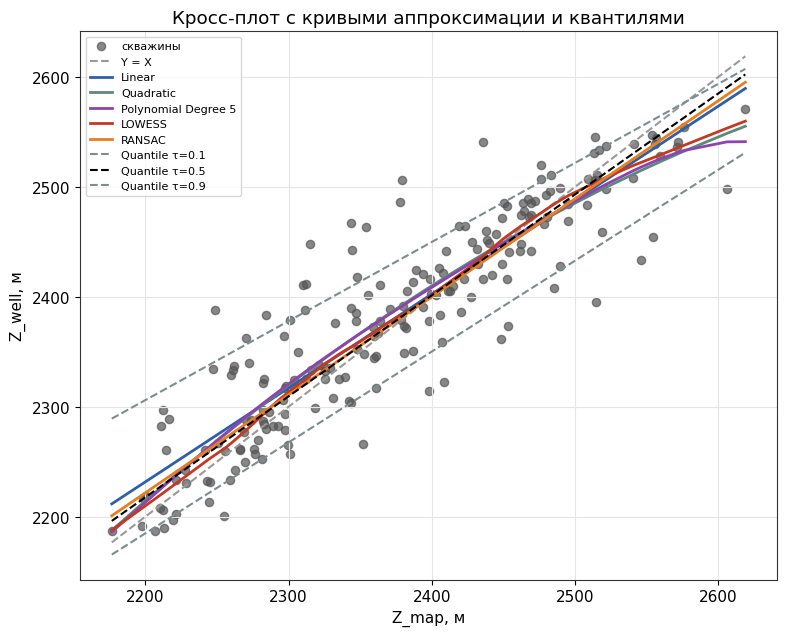

In [14]:
order = np.argsort(x)
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.scatter(x, y, s=35, c="#555", alpha=.7, label="скважины")
lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "--", color="#999", label="Y = X")
# FitStats.residuals = Predicted − Actual, поэтому Predicted = residuals + y
for a, colr in [("Linear", BLUE), ("Quadratic", "#5C8A7A"), ("Polynomial Degree 5", "#8E44AD"),
                ("LOWESS", RED), ("RANSAC", "#E67E22")]:
    s = sq.compute_fit_stats(x, y, a)
    ax.plot(x[order], (s.residuals + y)[order], color=colr, lw=2, label=a)
for tau, colr in [(0.1, "#7F8C8D"), (0.5, "black"), (0.9, "#7F8C8D")]:
    s = sq.compute_quantile_stats(x, y, tau)
    ax.plot(x[order], (s.residuals + y)[order], ls="--", color=colr, lw=1.5, label=f"Quantile τ={tau}")
ax.set_xlabel("Z_map, м"); ax.set_ylabel("Z_well, м")
ax.set_title("Кросс-плот с кривыми аппроксимации и квантилями")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Важно:** для τ = 0.1 и 0.9 R²_fit может быть отрицательным — это нормально. Квантильная регрессия описывает границы разброса, поэтому такие кривые оцениваются по уравнению и Bias, а не по R².

__Карта невязок и выбросы (Шаг 1)__

Карта невязок в плане показывает зоны систематического смещения (качество сейсмики, тектонические осложнения).

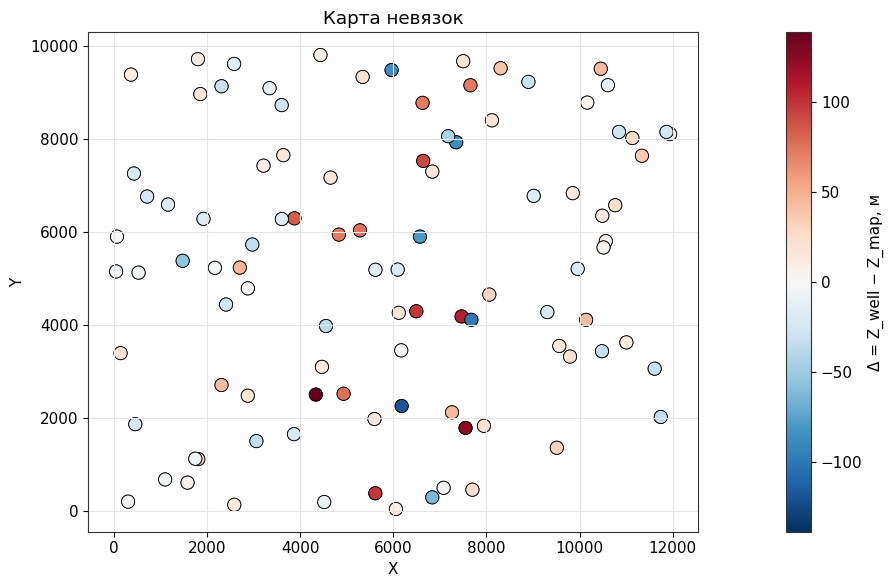

In [15]:
fig, ax = plt.subplots(figsize=(18, 6))
vmax = np.abs(basic.residuals).max()
sc = ax.scatter(df["X_coord"], df["Y_coord"], c=basic.residuals, cmap="RdBu_r",
                vmin=-vmax, vmax=vmax, s=90, edgecolor="black", linewidth=.6)
plt.colorbar(sc, label="Δ = Z_well − Z_map, м")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_aspect("equal")
ax.set_title("Карта невязок")
plt.tight_layout()
plt.show()

Выбросы оцениваются четырьмя независимыми правилами одновременно: sigma (|r| > 2σ), IQR ([Q1 − 1.5·IQR, Q3 + 1.5·IQR]), modified z-score (|0.6745·(r − median)/MAD| > 3.5) и перцентили (вне [Q05, Q95]).

In [16]:
def detect_outliers(r, sigma_thr=2.0):
    r = np.asarray(r, dtype=float)
    med = np.median(r)
    sd = r.std(ddof=1)
    q05, q25, q75, q95 = np.quantile(r, [0.05, 0.25, 0.75, 0.95])
    iqr = q75 - q25
    mad = np.median(np.abs(r - med))
    modz = 0.6745 * (r - med) / mad if mad > 0 else np.zeros_like(r)
    return {
        "sigma": np.abs(r) > sigma_thr * sd,
        "IQR": (r < q25 - 1.5 * iqr) | (r > q75 + 1.5 * iqr),
        "modified z": np.abs(modz) > 3.5,
        "P05–P95": (r < q05) | (r > q95),
    }

masks = detect_outliers(basic.residuals)
print({k: int(v.sum()) for k, v in masks.items()})

flags = pd.DataFrame(masks)
flags["methods"] = flags.sum(axis=1)
out = df.loc[flags["methods"] > 0, ["well_id", "X_coord", "Y_coord", "Zprm_well", "tectonic_zone"]].copy() \
        if "tectonic_zone" in df.columns else df.loc[flags["methods"] > 0, ["well_id", "X_coord", "Y_coord", "Zprm_well"]].copy()
out["Δ, м"] = basic.residuals[flags["methods"] > 0]
out["методов"] = flags.loc[flags["methods"] > 0, "methods"].to_numpy()
out.sort_values("методов", ascending=False)

{'sigma': 16, 'IQR': 22, 'modified z': 7, 'P05–P95': 20}


,well_id,X_coord,Y_coord,Zprm_well,tectonic_zone,"Δ, м",методов
88,W-045,7676.6,4116.5,2498.00,Central_Graben,-107.97,4
101,W-051,4335.2,2510.0,2387.89,Central_Graben,139.04,4
100,W-051,4335.2,2510.0,2447.70,Central_Graben,132.47,4
50,W-026,6178.7,2264.2,2433.75,Central_Graben,-112.22,4
51,W-026,6178.7,2264.2,2395.04,Central_Graben,-119.78,4
56,W-029,7550.7,1794.1,2505.89,Central_Graben,126.97,4
57,W-029,7550.7,1794.1,2467.49,Central_Graben,124.00,4
89,W-045,7676.6,4116.5,2454.42,Central_Graben,-99.74,3
185,W-093,5612.8,389.9,2411.32,Central_Graben,98.84,3
184,W-093,5612.8,389.9,2463.77,Central_Graben,110.03,3


<div class="alert alert-info">
  <b> * <a href="#ch8">к содержанию</a> </b> 
</div>

---

## __Шаг 2: Кросс-валидация__ <a class="anchor" id="ch8_3"></a> 

Строим суррогатную поверхность `Z_well ~ f(X, Y)` и валидируем её **процесс построения**. Это иллюстрация того, как следовало бы кросс-валидировать сам метод построения карты, если бы он использовал скважины в калибровке.

Запускаются все схемы движка. Random K-Fold включён как заведомо оптимистичная база для контраста и в выборе лучшей схемы не участвует. Stratified by Zone появляется только при наличии `tectonic_zone` с двумя и более значениями.

In [17]:
from scipy.spatial.distance import pdist

coords = df[["X_coord", "Y_coord"]].to_numpy(float)
y_true = df["Zprm_well"].to_numpy(float)
n_wells = df["well_id"].nunique()
median_dist = float(np.median(pdist(coords)))

def recommend_cv(n, md):
    return {
        "k (Random K-Fold)": 5 if n < 20 else 7 if n < 50 else 10 if n < 150 else 12,
        "grid_n (Block/Buffered)": 5 if md < 300 else 4 if md < 600 else 3 if md < 1000 else 2,
        "buffer, м (Buffered)": 0.5 * md,
        "cv_repeats (Leave-P-Out)": 100 if n < 30 else 50 if n < 100 else 30 if n < 300 else 20,
        "radius, м (Spatial LPO)": md,
    }

print(f"скважин: {n_wells}, медианное расстояние между скважинами: {median_dist:.0f} м")
pd.Series(recommend_cv(n_wells, median_dist), name="рекомендовано").round(1).to_frame()

скважин: 100, медианное расстояние между скважинами: 5657 м


,рекомендовано
k (Random K-Fold),10.0
grid_n (Block/Buffered),2.0
"buffer, м (Buffered)",2828.7
cv_repeats (Leave-P-Out),30.0
"radius, м (Spatial LPO)",5657.5


In [18]:
rows = []
for f in [0.5, 1.0, 1.5, 2.0, 3.0]:
    preds, _ = sq.cv_variogram(df, degree=1, variogram_factor=f)
    m = ~np.isnan(preds)
    rows.append({"variogram_factor": f,
                 "радиус исключения, м": sq.estimate_correlation_range(coords) * f,
                 "RMSE, м": np.sqrt(np.mean((preds[m] - y_true[m]) ** 2)),
                 "скважин с прогнозом": int(m.sum())})
pd.DataFrame(rows).round(2)

E:\envs\py310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
E:\envs\py310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,variogram_factor,"радиус исключения, м","RMSE, м",скважин с прогнозом
0,0.5,2828.74,45.84,200
1,1.0,5657.47,52.41,200
2,1.5,8486.21,52.77,174
3,2.0,11314.95,45.58,60
4,3.0,16972.42,NaN,0


In [19]:
results, comparison = sq.run_all_cv(df, degree=1, k=5, grid_n=3)
comparison.round(2)

,rmse,mae,bias,rmse_fold_mean,rmse_fold_median,rmse_fold_min,rmse_fold_max,rmse_fold_std,rmse_fold_range
CV scheme,,,,,,,,,
Random K-Fold,42.17,32.28,0.15,42.01,42.10,36.79,47.88,4.09,11.09
Leave-One-Well-Out,42.60,32.44,0.09,32.95,25.23,2.32,118.58,27.13,116.26
Block CV,44.91,34.89,1.08,40.17,41.76,20.04,65.81,17.10,45.78
Buffered CV,44.91,34.89,1.08,40.17,41.76,20.04,65.81,17.10,45.78
Leave-P-Out,42.16,32.15,0.03,42.34,42.88,23.75,55.78,7.77,32.03
Spatial Leave-P-Out,42.09,32.21,-1.09,37.40,31.96,9.03,74.91,16.45,65.88
Stratified by Zone,54.91,43.91,6.65,50.53,59.29,28.74,63.56,18.99,34.82
Distance-based exclusion CV,52.41,41.30,7.18,41.30,33.46,0.35,130.91,32.35,130.55


In [20]:
comparison = comparison.copy()
comparison["score"] = comparison["rmse"] + comparison["rmse_fold_std"]
# Random K-Fold заведомо оптимистичен, поэтому в выборе лучшей схемы не участвует
candidates = comparison.drop(index="Random K-Fold")
best = candidates["score"].idxmin()
print(f"Лучшая схема по score = RMSE + RMSE_fold_std (без Random K-Fold): {best}")
comparison.sort_values("score")[["rmse", "rmse_fold_std", "score"]].round(2)

Лучшая схема по score = RMSE + RMSE_fold_std (без Random K-Fold): Leave-P-Out


,rmse,rmse_fold_std,score
CV scheme,,,
Random K-Fold,42.17,4.09,46.27
Leave-P-Out,42.16,7.77,49.93
Spatial Leave-P-Out,42.09,16.45,58.54
Block CV,44.91,17.10,62.01
Buffered CV,44.91,17.10,62.01
Leave-One-Well-Out,42.60,27.13,69.74
Stratified by Zone,54.91,18.99,73.90
Distance-based exclusion CV,52.41,32.35,84.76


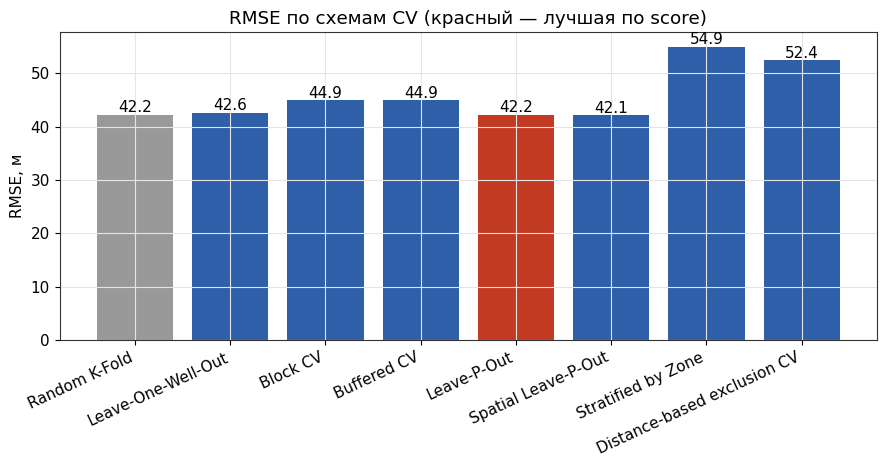

Random K-Fold RMSE = 42.2 м, наихудшая из пространственных схем = 54.9 м (разница 12.7 м — мера оптимизма случайного разбиения)


In [21]:
fig, ax = plt.subplots(figsize=(9, 4.8))
colors = [RED if i == best else ("#999999" if i == "Random K-Fold" else BLUE)
          for i in comparison.index]
bars = ax.bar(comparison.index, comparison["rmse"], color=colors)
for b, v in zip(bars, comparison["rmse"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}", ha="center")
ax.set_ylabel("RMSE, м")
ax.set_title("RMSE по схемам CV (красный — лучшая по score)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

gap = comparison.loc["Random K-Fold", "rmse"]
worst = comparison.drop(index="Random K-Fold")["rmse"].max()
print(f"Random K-Fold RMSE = {gap:.1f} м, наихудшая из пространственных схем = {worst:.1f} м "
      f"(разница {worst - gap:.1f} м — мера оптимизма случайного разбиения)")

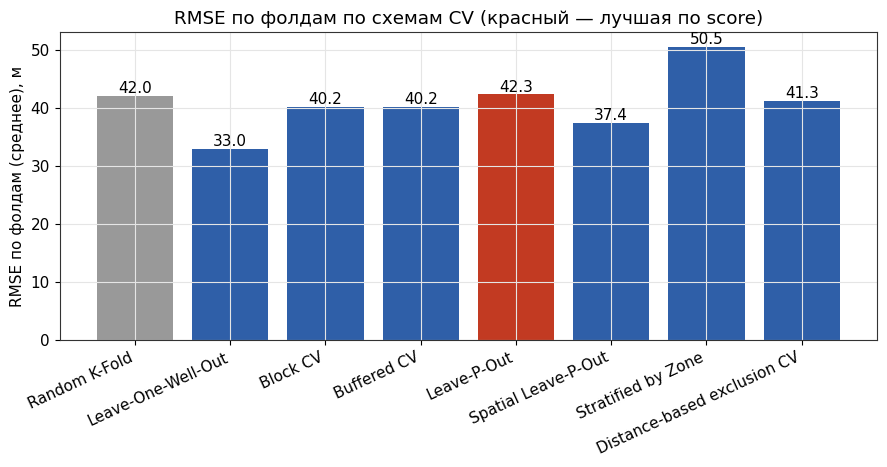

In [22]:
# Столбчатая диаграмма: среднее RMSE по фолдам для каждой схемы CV
fig, ax = plt.subplots(figsize=(9, 4.8))
colors = [RED if i == best else ("#999999" if i == "Random K-Fold" else BLUE)
          for i in comparison.index]
bars = ax.bar(comparison.index, comparison["rmse_fold_mean"], color=colors)
for b, v in zip(bars, comparison["rmse_fold_mean"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}", ha="center")
ax.set_ylabel("RMSE по фолдам (среднее), м")
ax.set_title("RMSE по фолдам по схемам CV (красный — лучшая по score)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

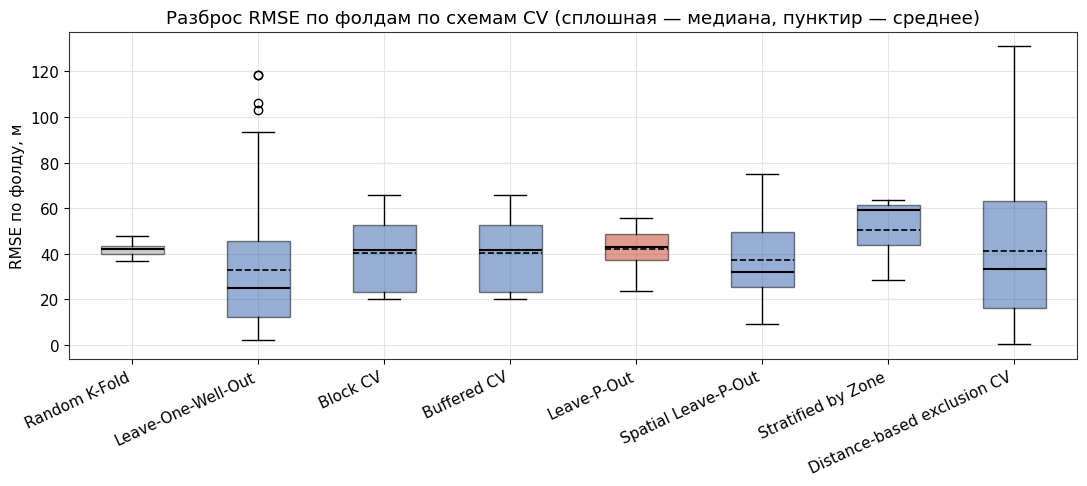

In [23]:
# Boxplot разброса RMSE по фолдам: медиана — сплошная, среднее — пунктир, выбросы — точки
labels, data, colors = [], [], []
for name in comparison.index:
    f = results[name].get("folds")
    vals = f["rmse"].dropna().to_numpy(float) if f is not None and len(f) else np.array([])
    if len(vals) == 0:
        continue
    labels.append(name)
    data.append(vals)
    colors.append(RED if name == best else ("#999999" if name == "Random K-Fold" else BLUE))

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(data, patch_artist=True, showmeans=True, meanline=True,
                medianprops=dict(color="black", linewidth=1.5),
                meanprops=dict(color="black", linestyle="--", linewidth=1.2))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("RMSE по фолду, м")
ax.set_title("Разброс RMSE по фолдам по схемам CV (сплошная — медиана, пунктир — среднее)")
plt.tight_layout()
plt.show()

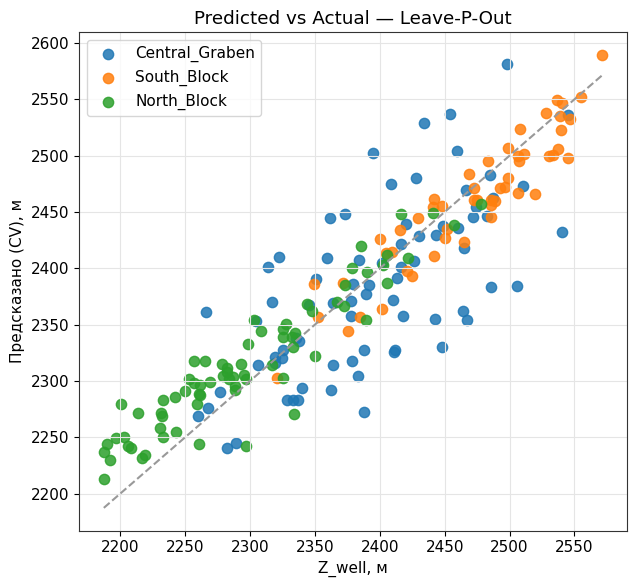

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 6))
preds = results[best]["preds"]
zones = df["tectonic_zone"] if "tectonic_zone" in df.columns else pd.Series("all", index=df.index)
palette = plt.cm.tab10.colors
for i, zone in enumerate(zones.unique()):
    m = (zones == zone).to_numpy()
    ax.scatter(df.loc[m, "Zprm_well"], preds[m], label=str(zone), s=55, alpha=.85,
               color=palette[i % len(palette)])
lo, hi = df["Zprm_well"].min(), df["Zprm_well"].max()
ax.plot([lo, hi], [lo, hi], "--", color="#999")
ax.set_xlabel("Z_well, м"); ax.set_ylabel("Предсказано (CV), м")
ax.legend(); ax.set_title(f"Predicted vs Actual — {best}")
plt.tight_layout()
plt.show()

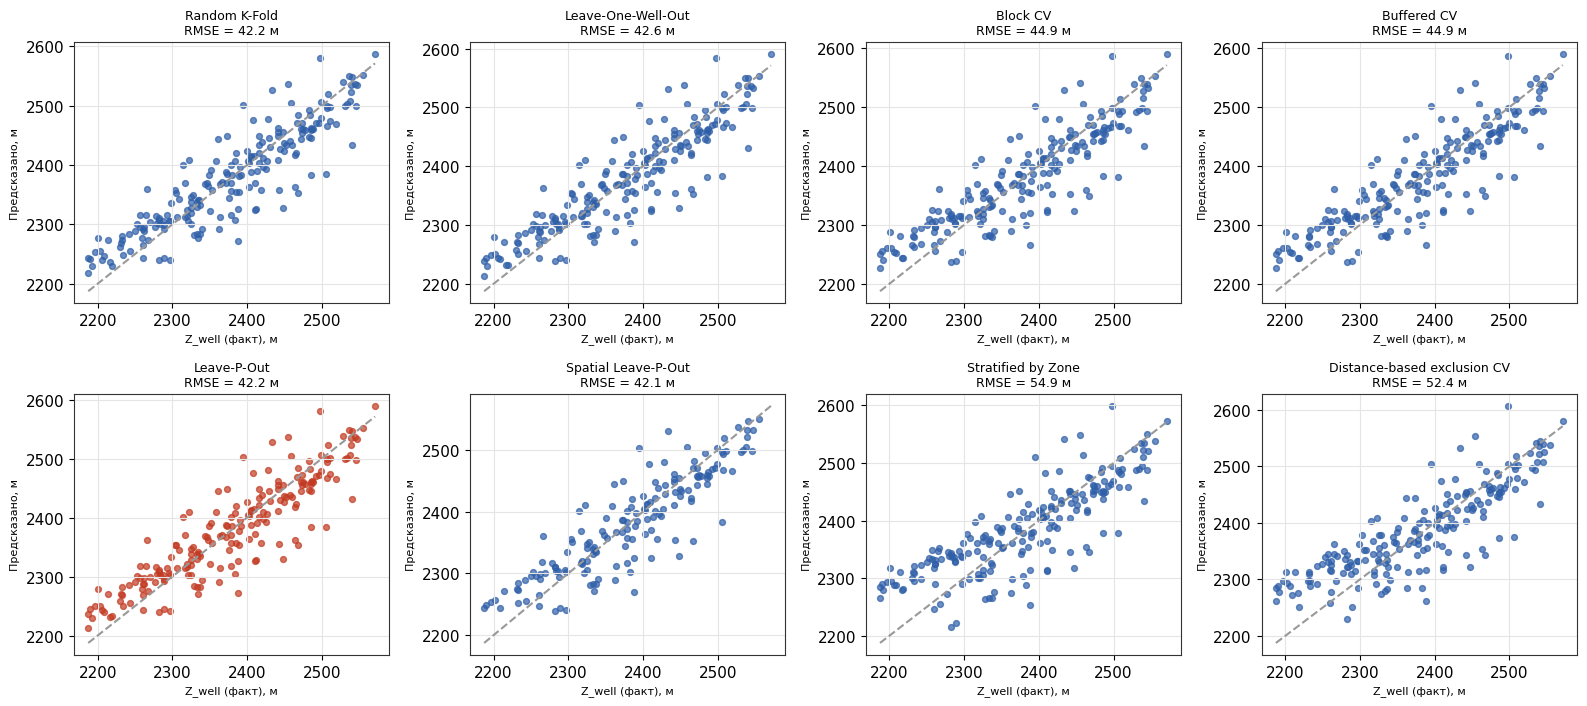

In [25]:
names = list(comparison.index)
ncol = 4
nrow = int(np.ceil(len(names) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.6 * nrow), squeeze=False)
for ax, name in zip(axes.ravel(), names):
    p = results[name]["preds"]
    m = ~np.isnan(p)
    ax.scatter(y_true[m], p[m], s=18, alpha=.7, color=RED if name == best else BLUE)
    lo_, hi_ = y_true.min(), y_true.max()
    ax.plot([lo_, hi_], [lo_, hi_], "--", color="#999")
    ax.set_title(f"{name}\nRMSE = {comparison.loc[name, 'rmse']:.1f} м", fontsize=9)
    ax.set_xlabel("Z_well (факт), м", fontsize=8); ax.set_ylabel("Предсказано, м", fontsize=8)
for ax in axes.ravel()[len(names):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

In [26]:
for deg in [1, 2]:
    _, comp = sq.run_all_cv(df, degree=deg, k=5, grid_n=3)
    print(f"--- degree={deg} ---")
    print(comp[["rmse", "mae", "bias"]].round(2), "\n")

--- degree=1 ---
                              rmse    mae  bias
CV scheme                                      
Random K-Fold                42.17  32.28  0.15
Leave-One-Well-Out           42.60  32.44  0.09
Block CV                     44.91  34.89  1.08
Buffered CV                  44.91  34.89  1.08
Leave-P-Out                  42.16  32.15  0.03
Spatial Leave-P-Out          42.09  32.21 -1.09
Stratified by Zone           54.91  43.91  6.65
Distance-based exclusion CV  52.41  41.30  7.18 

--- degree=2 ---
                              rmse    mae  bias
CV scheme                                      
Random K-Fold                41.56  31.89  0.23
Leave-One-Well-Out           42.06  32.10  0.04
Block CV                     44.54  35.17  0.47
Buffered CV                  44.54  35.17  0.47
Leave-P-Out                  41.57  31.74  0.05
Spatial Leave-P-Out          42.49  33.00 -0.35
Stratified by Zone           56.68  46.87  4.56
Distance-based exclusion CV  52.90  42.27  5.93 



**Вывод для проверки:** сравните RMSE для степеней 1 и 2. Если квадратичная поверхность хуже на CV — это признак переобучения тренда на разреженном скважинном контроле.

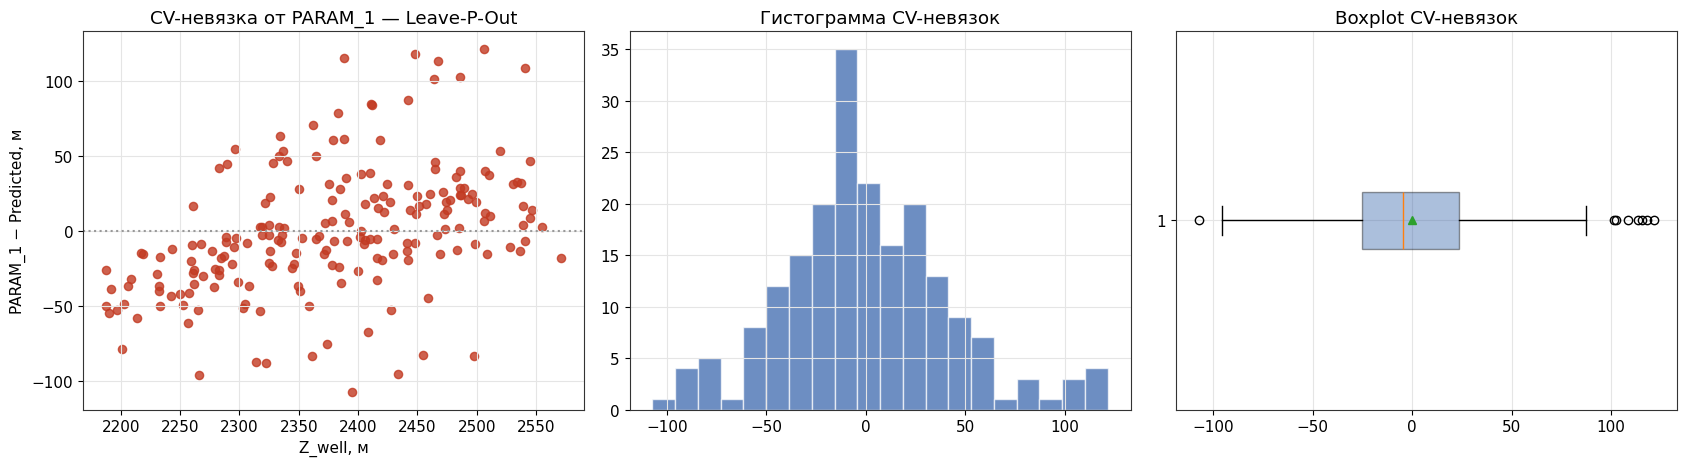

,CV-невязка
Count,200.00
μ (mean),-0.03
median,-4.69
mode,-2.25
σ (std),42.27
variance,1786.47
"CV, %",-135509.44
min,-107.24
Q05,-67.28
Q25,-25.26


выбросы по методам: {'sigma': 14, 'IQR': 8, 'modified z': 0, 'P05–P95': 20}


In [27]:
best_preds = results[best]["preds"]
m = ~np.isnan(best_preds)
cv_res = y_true[m] - best_preds[m]            # PARAM_1 − Predicted (как на графике CV-невязок)
p1 = y_true[m]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].scatter(p1, cv_res, s=35, color=RED, alpha=.8)
axes[0].axhline(0, ls=":", color="#999")
axes[0].set_xlabel("Z_well, м"); axes[0].set_ylabel("PARAM_1 − Predicted, м")
axes[0].set_title(f"CV-невязка от PARAM_1 — {best}")
axes[1].hist(cv_res, bins=20, color=BLUE, alpha=.7, edgecolor="white")
axes[1].set_title("Гистограмма CV-невязок")
axes[2].boxplot(cv_res, vert=False, showmeans=True, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=.4))
axes[2].set_title("Boxplot CV-невязок")
plt.tight_layout(); plt.show()

display(pd.DataFrame({"CV-невязка": param_stats(cv_res)}).round(2))
cv_m = detect_outliers(cv_res)
print("выбросы по методам:", {k: int(v.sum()) for k, v in cv_m.items()})

__Разбор по фолдам и тектоническим зонам (Шаг 2, детально)__

In [28]:
if "Stratified by Zone" in results:
    results["Stratified by Zone"]["folds"]
else:
    print("Stratified by Zone пропущена: нет колонки tectonic_zone с двумя и более значениями")

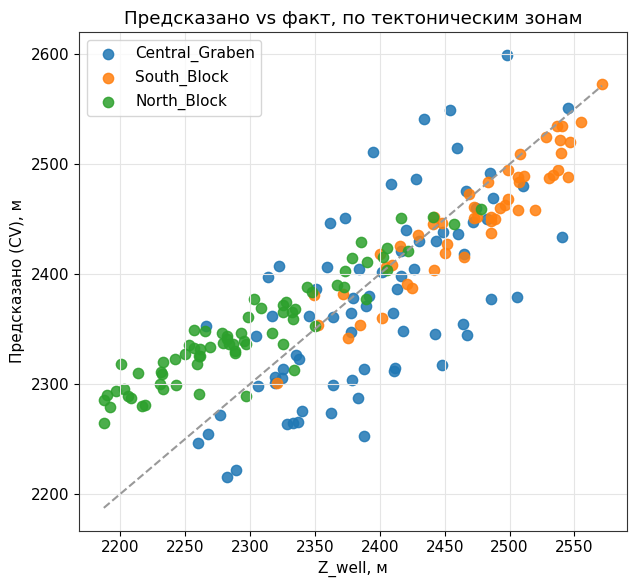

In [29]:
if "Stratified by Zone" in results:
    fig, ax = plt.subplots(figsize=(6.5, 6))
    preds = results["Stratified by Zone"]["preds"]
    zones = df["tectonic_zone"]
    for i, zone in enumerate(zones.unique()):
        m = (zones == zone).to_numpy()
        ax.scatter(df.loc[m, "Zprm_well"], preds[m], label=str(zone), s=55, alpha=.85,
                   color=plt.cm.tab10.colors[i % 10])
    lo, hi = df["Zprm_well"].min(), df["Zprm_well"].max()
    ax.plot([lo, hi], [lo, hi], "--", color="#999")
    ax.set_xlabel("Z_well, м"); ax.set_ylabel("Предсказано (CV), м")
    ax.legend(); ax.set_title("Предсказано vs факт, по тектоническим зонам")
    plt.tight_layout()
    plt.show()

In [30]:
comparison[["rmse_fold_mean", "rmse_fold_median", "rmse_fold_min",
            "rmse_fold_max", "rmse_fold_std", "rmse_fold_range"]].round(2)

,rmse_fold_mean,rmse_fold_median,rmse_fold_min,rmse_fold_max,rmse_fold_std,rmse_fold_range
CV scheme,,,,,,
Random K-Fold,42.01,42.10,36.79,47.88,4.09,11.09
Leave-One-Well-Out,32.95,25.23,2.32,118.58,27.13,116.26
Block CV,40.17,41.76,20.04,65.81,17.10,45.78
Buffered CV,40.17,41.76,20.04,65.81,17.10,45.78
Leave-P-Out,42.34,42.88,23.75,55.78,7.77,32.03
Spatial Leave-P-Out,37.40,31.96,9.03,74.91,16.45,65.88
Stratified by Zone,50.53,59.29,28.74,63.56,18.99,34.82
Distance-based exclusion CV,41.30,33.46,0.35,130.91,32.35,130.55


**Наблюдение:** зона, которая даёт систематически больший разброс, — кандидат на проблему скоростной модели или зону разломов / потери когерентности сейсмики. Конкретная зона зависит от данных; проверьте по таблице выше.

__Выбросы в кросс-валидации (LOWO)__

In [31]:
preds_lowo = results["Leave-One-Well-Out"]["preds"]
cv_resid = preds_lowo - df["Zprm_well"].to_numpy()      # Predicted − Actual
cv_masks = detect_outliers(cv_resid)
print({k: int(v.sum()) for k, v in cv_masks.items()})

sel = cv_masks["sigma"]
out_cv = df.loc[sel, ["well_id", "X_coord", "Y_coord", "Zprm_well"]].copy()
out_cv["Predicted_LOWO"] = preds_lowo[sel]
out_cv["Residual"] = cv_resid[sel]
out_cv

{'sigma': 14, 'IQR': 8, 'modified z': 0, 'P05–P95': 20}


,well_id,X_coord,Y_coord,Zprm_well,Predicted_LOWO,Residual
30,W-016,6642.0,7529.8,2410.58,2324.527541,-86.052459
36,W-019,7466.2,4189.0,2540.63,2431.621877,-109.008123
37,W-019,7466.2,4189.0,2485.79,2382.336520,-103.453480
45,W-023,7350.5,7930.2,2322.59,2410.808107,88.218107
50,W-026,6178.7,2264.2,2433.75,2531.055580,97.305580
51,W-026,6178.7,2264.2,2395.04,2503.942247,108.902247
56,W-029,7550.7,1794.1,2505.89,2383.342831,-122.547169
57,W-029,7550.7,1794.1,2467.49,2353.022257,-114.467743
60,W-031,5962.5,9481.2,2314.11,2401.876846,87.766846
61,W-031,5962.5,9481.2,2265.75,2362.143151,96.393151


<div class="alert alert-info">
  <b> * <a href="#ch8">к содержанию</a> </b> 
</div>

---

## __Шаг 3: Диагностика по категориям__ <a class="anchor" id="ch8_4"></a> 

Та же пара параметров, но по любой категориальной колонке: тектоническая зона, горизонт, флаг качества.

In [32]:
cat_cols = [c for c in ["tectonic_zone", "horizon_id", "well_category",
                        "reservoir_flag", "fluid_type", "quality_flag"] if c in df.columns]
for col in cat_cols:
    rows = []
    for k, s in df.groupby(col):
        r = s["Zprm_well"] - s["Zprm_map"]
        rows.append({col: k, "n": len(s), "RMSE, м": np.sqrt((r ** 2).mean()),
                     "Bias, м": r.mean()})
    print(f"--- по {col} ---")
    print(pd.DataFrame(rows).round(2).to_string(index=False), "\n")

--- по tectonic_zone ---
 tectonic_zone  n  RMSE, м  Bias, м
Central_Graben 76    65.12    16.68
   North_Block 72    25.18    -1.36
   South_Block 52    25.31     2.66 

--- по horizon_id ---
   horizon_id   n  RMSE, м  Bias, м
Top_Reservoir 100    44.43     6.93
     Top_Seal 100    45.15     6.15 

--- по well_category ---
well_category   n  RMSE, м  Bias, м
    appraisal  44    61.06    22.10
  exploration  22    22.81    -0.72
   production 134    41.05     2.62 

--- по reservoir_flag ---
reservoir_flag   n  RMSE, м  Bias, м
 non_reservoir  58    46.45     8.42
     reservoir 142    44.10     5.77 

--- по fluid_type ---
   fluid_type  n  RMSE, м  Bias, м
          gas 26    31.55    18.68
non_reservoir 58    46.45     8.42
          oil 66    48.35     6.21
        water 50    43.80    -1.53 



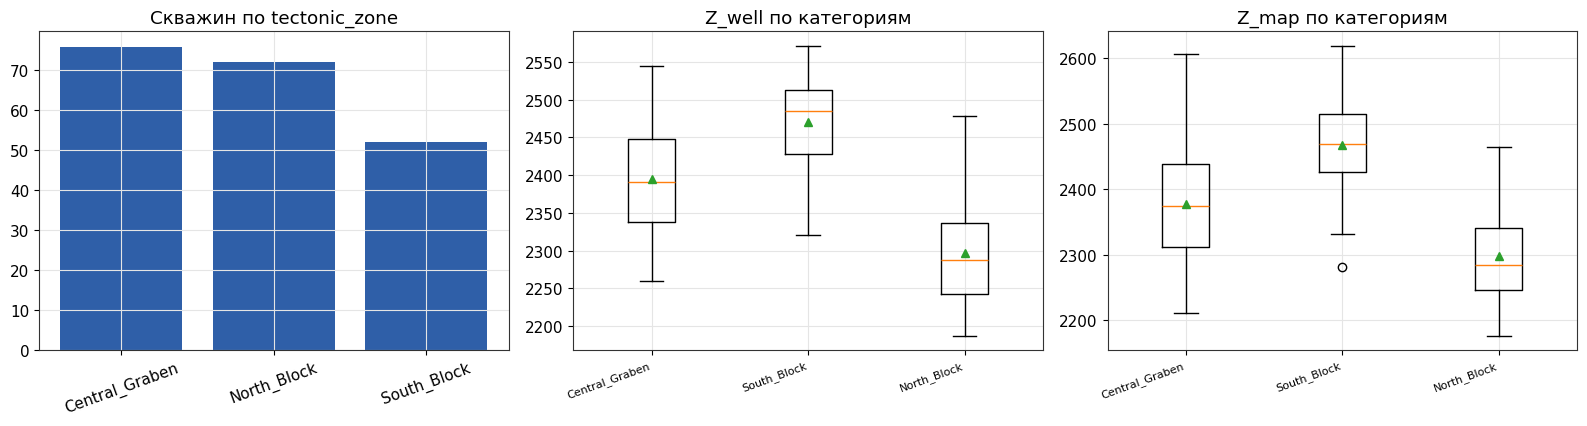

,tectonic_zone,n,Z_well μ,Z_well σ,Z_map μ,Z_map σ
0,Central_Graben,76,2394.35,68.52,2377.67,87.11
1,South_Block,52,2470.54,60.04,2467.88,70.04
2,North_Block,72,2296.71,71.54,2298.08,70.06


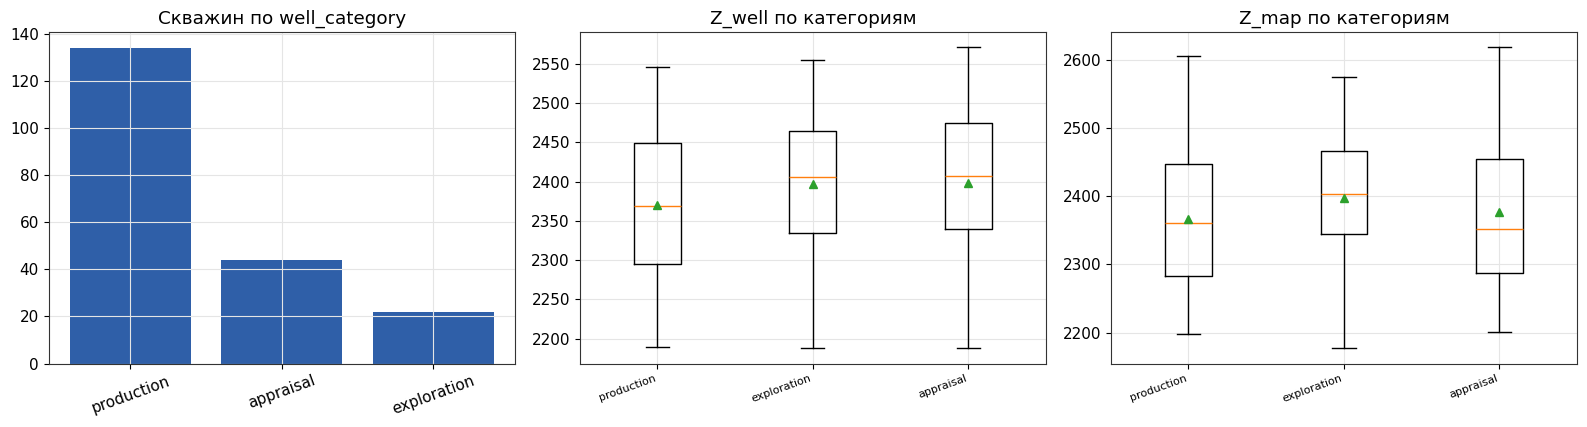

,well_category,n,Z_well μ,Z_well σ,Z_map μ,Z_map σ
0,production,134,2369.69,93.32,2367.07,99.47
1,exploration,22,2396.73,101.00,2397.45,101.23
2,appraisal,44,2398.54,100.32,2376.44,106.98


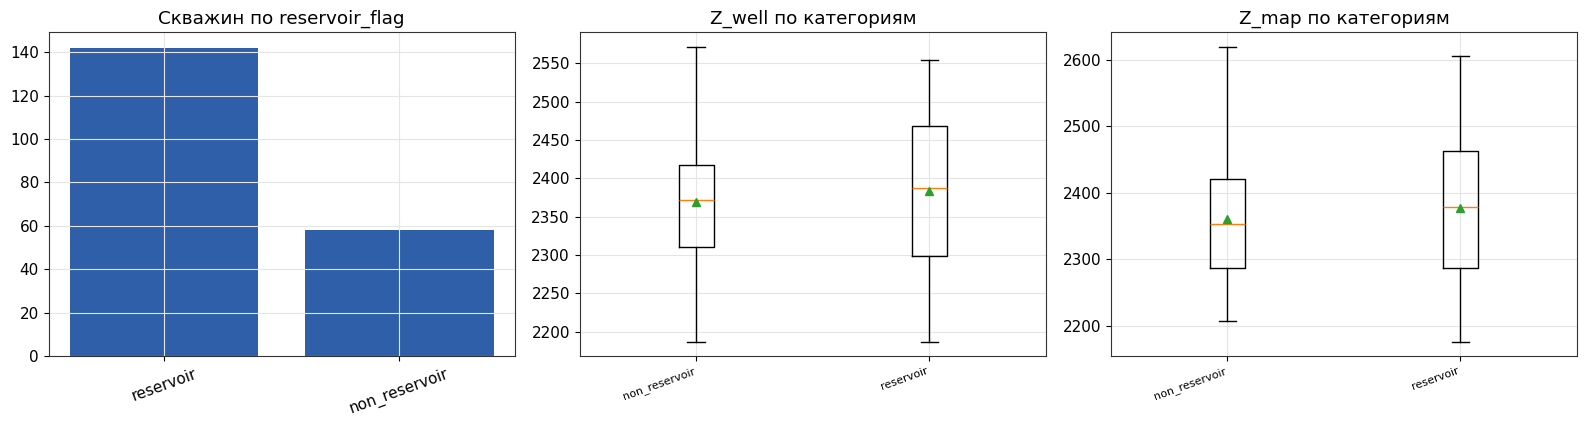

,reservoir_flag,n,Z_well μ,Z_well σ,Z_map μ,Z_map σ
0,non_reservoir,58,2368.96,84.49,2360.54,94.59
1,reservoir,142,2383.11,100.54,2377.34,103.83


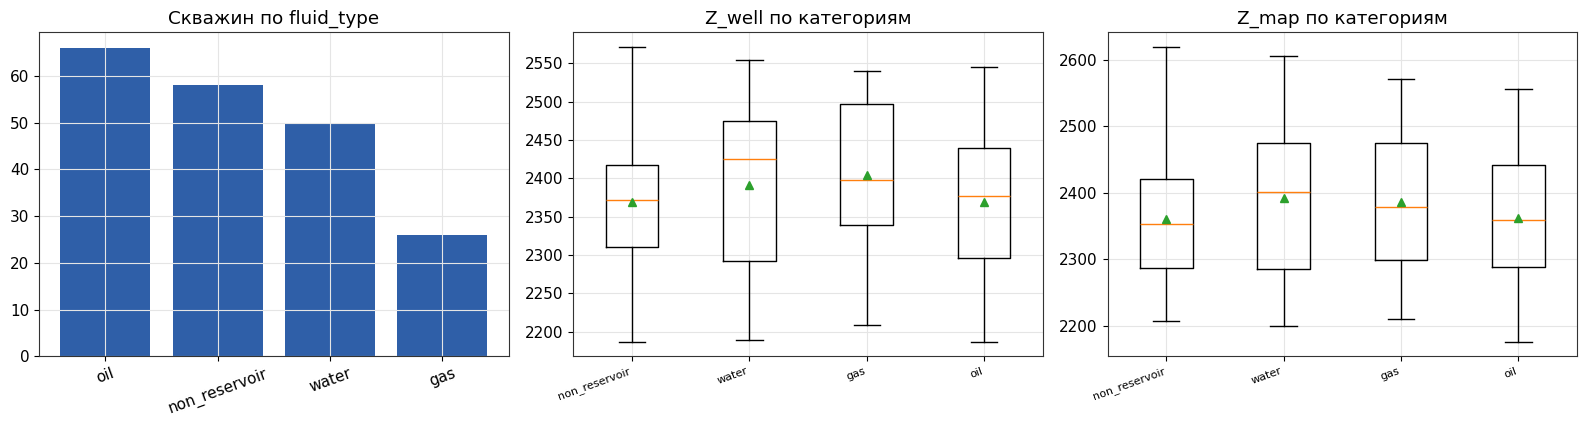

,fluid_type,n,Z_well μ,Z_well σ,Z_map μ,Z_map σ
0,non_reservoir,58,2368.96,84.49,2360.54,94.59
1,water,50,2390.78,108.53,2392.31,112.35
2,gas,26,2404.51,98.10,2385.82,102.94
3,oil,66,2368.88,94.41,2362.67,96.83


In [33]:
for col in [c for c in ["tectonic_zone", "well_category", "reservoir_flag", "fluid_type"] if c in df.columns]:
    cats = list(df[col].dropna().unique())
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    cnt = df[col].value_counts()
    axes[0].bar(cnt.index.astype(str), cnt.values, color=BLUE)
    axes[0].set_title(f"Скважин по {col}")
    for ax, pcol, lbl in [(axes[1], "Zprm_well", "Z_well"), (axes[2], "Zprm_map", "Z_map")]:
        ax.boxplot([df.loc[df[col] == c, pcol] for c in cats], showmeans=True)
        ax.set_xticks(range(1, len(cats) + 1))
        ax.set_xticklabels([str(c) for c in cats], rotation=20, ha="right", fontsize=8)
        ax.set_title(f"{lbl} по категориям")
    axes[0].tick_params(axis="x", rotation=20)
    plt.tight_layout(); plt.show()

    stat_rows = []
    for c in cats:
        s = df[df[col] == c]
        stat_rows.append({col: c, "n": len(s),
                          "Z_well μ": s["Zprm_well"].mean(), "Z_well σ": s["Zprm_well"].std(ddof=1),
                          "Z_map μ": s["Zprm_map"].mean(), "Z_map σ": s["Zprm_map"].std(ddof=1)})
    display(pd.DataFrame(stat_rows).round(2))

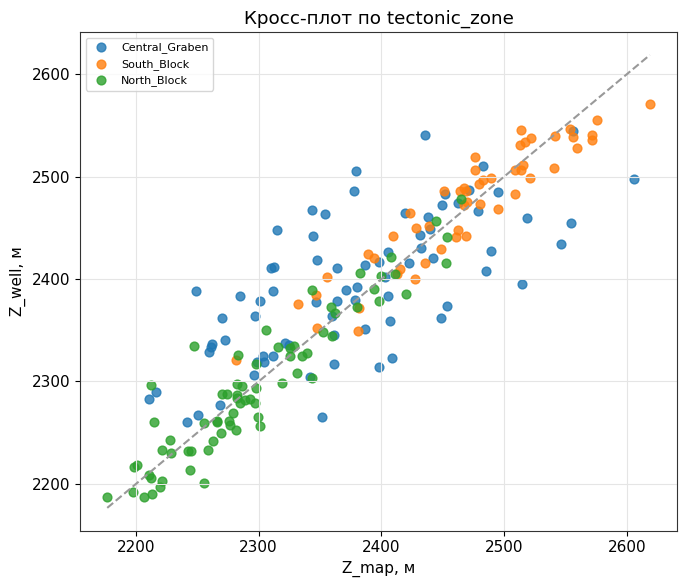

--- линейная аппроксимация по tectonic_zone ---
 tectonic_zone  n  R²_fit  RMSE, м  Bias, м                  Уравнение
Central_Graben 76   0.480   49.101      0.0 y = 0.54479·x + 1099.01861
   South_Block 52   0.874   21.079     -0.0  y = 0.80159·x + 492.31443
   North_Block 72   0.877   24.954     -0.0   y = 0.95601·x + 99.72282 



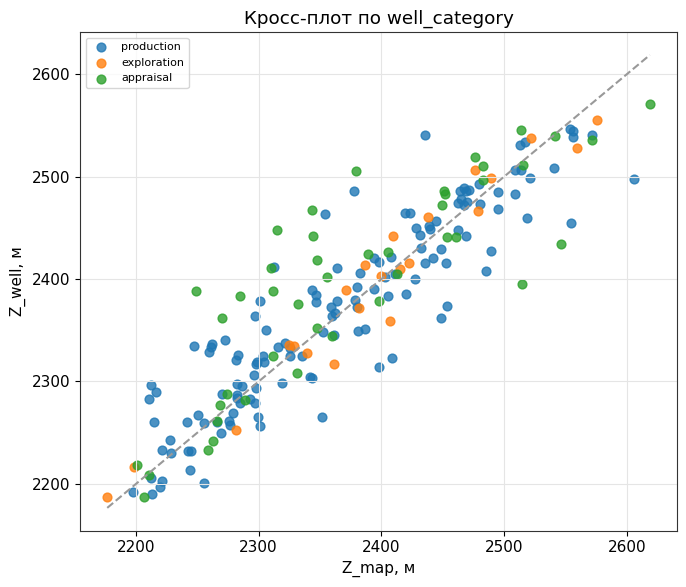

--- линейная аппроксимация по well_category ---
well_category   n  R²_fit  RMSE, м  Bias, м                 Уравнение
   production 134   0.830   38.346      0.0 y = 0.85460·x + 346.79155
  exploration  22   0.947   22.616      0.0  y = 0.97115·x + 68.46079
    appraisal  44   0.718   52.622      0.0 y = 0.79483·x + 509.68208 



In [34]:
for col in [c for c in ["tectonic_zone", "well_category"] if c in df.columns]:
    cats = list(df[col].dropna().unique())
    fig, ax = plt.subplots(figsize=(7, 6))
    for i, c in enumerate(cats):
        m = (df[col] == c).to_numpy()
        ax.scatter(df.loc[m, "Zprm_map"], df.loc[m, "Zprm_well"], s=40, alpha=.8,
                   color=plt.cm.tab10.colors[i % 10], label=str(c))
    lo_, hi_ = min(df["Zprm_map"].min(), df["Zprm_well"].min()), max(df["Zprm_map"].max(), df["Zprm_well"].max())
    ax.plot([lo_, hi_], [lo_, hi_], "--", color="#999")
    ax.set_xlabel("Z_map, м"); ax.set_ylabel("Z_well, м"); ax.legend(fontsize=8)
    ax.set_title(f"Кросс-плот по {col}")
    plt.tight_layout(); plt.show()

    rows = []
    for c in cats:
        d = df[df[col] == c]
        if len(d) < 3:
            continue
        s = sq.compute_fit_stats(d["Zprm_map"].to_numpy(float), d["Zprm_well"].to_numpy(float), "Linear")
        rows.append({col: c, "n": len(d), "R²_fit": s.r2, "RMSE, м": s.rmse,
                     "Bias, м": s.bias, "Уравнение": s.equation})
    print(f"--- линейная аппроксимация по {col} ---")
    print(pd.DataFrame(rows).round(3).to_string(index=False), "\n")

<div class="alert alert-info">
  <b> * <a href="#ch8">к содержанию</a> </b> 
</div>

---

## __Шаг 4: Фильтрация скважин__ <a class="anchor" id="ch8_5"></a> 

Проверяем устойчивость результата к сокращению выборки. В приложении доступны четыре режима:
- ручное исключение конкретных `well_id` (мультиселект);
- случайное исключение заданного процента (0–95%, с пересэмплированием);
- выделение точек кликом на cross-plot (Shift+клик, рамка Box, лассо Lasso), с кнопками «Применить исключение» и «Сбросить всё»;
- без фильтра.

В ноутбуке интерактивное выделение не воспроизводится, поэтому имитируем рамку: исключаем скважины, попадающие в заданный диапазон Z_well.

In [35]:
rng = np.random.default_rng(42)
wells = df["well_id"].unique()

manual_excl = list(wells[:5])                                      # ручной список
random_excl = list(rng.choice(wells, size=int(0.2 * len(wells)), replace=False))  # 20 %
z_lo, z_hi = df["Zprm_well"].quantile([0.8, 1.0])
box_excl = list(df.loc[df["Zprm_well"].between(z_lo, z_hi), "well_id"].unique())  # «рамка»

def row(name, d):
    s = sq.basic_crossplot_stats(d)
    return {"сценарий": name, "n": s.n, "R²_lin": s.r2, "slope": s.slope,
            "RMSE, м": s.rmse, "Bias, м": s.bias, "p-value": s.p_value}

scen = [
    row("Без фильтра", df),
    row("Ручное: 5 скважин", df[~df["well_id"].isin(manual_excl)]),
    row("Случайно: 20 %", df[~df["well_id"].isin(random_excl)]),
    row("Рамка: верхние 20 % по Z_well", df[~df["well_id"].isin(box_excl)]),
]
pd.DataFrame(scen).round(3)

,сценарий,n,R²_lin,slope,"RMSE, м","Bias, м",p-value
0,Без фильтра,200,0.810,0.855,44.792,6.538,0.0
1,Ручное: 5 скважин,190,0.801,0.852,45.543,6.435,0.0
2,Случайно: 20 %,160,0.803,0.863,45.523,4.865,0.0
3,Рамка: верхние 20 % по Z_well,148,0.696,0.779,45.158,5.837,0.0


In [36]:
stab = []
for seed in range(1, 6):
    r = np.random.default_rng(seed)
    excl = list(r.choice(wells, size=int(0.2 * len(wells)), replace=False))
    s = sq.basic_crossplot_stats(df[~df["well_id"].isin(excl)])
    stab.append({"seed": seed, "n": s.n, "R²_lin": s.r2, "slope": s.slope,
                 "RMSE, м": s.rmse, "Bias, м": s.bias})
stab = pd.DataFrame(stab)
display(stab.round(3))
print("Сводка по 5 наборам (по 20 % скважин исключено):")
stab[["R²_lin", "slope", "RMSE, м", "Bias, м"]].agg(["mean", "std", "min", "max"]).round(3)

,seed,n,R²_lin,slope,"RMSE, м","Bias, м"
0,1,160,0.819,0.853,44.324,10.973
1,2,160,0.802,0.853,45.200,7.527
2,3,160,0.809,0.858,44.638,10.497
3,4,160,0.806,0.856,44.584,7.058
4,5,160,0.818,0.894,43.675,11.107


Сводка по 5 наборам (по 20 % скважин исключено):


,R²_lin,slope,"RMSE, м","Bias, м"
mean,0.811,0.863,44.484,9.433
std,0.008,0.018,0.554,1.974
min,0.802,0.853,43.675,7.058
max,0.819,0.894,45.200,11.107


In [37]:
after = df[~df["well_id"].isin(random_excl)]
rows = []
for label, d in [("до фильтрации", df), ("после: случайно 20 %", after)]:
    xx = d["Zprm_map"].to_numpy(float)
    yy = d["Zprm_well"].to_numpy(float)
    for a in ["Linear", "Polynomial Degree 5", "LOWESS"]:
        s = sq.compute_fit_stats(xx, yy, a)
        rows.append({"набор": label, "n": len(d), "кривая": a, "R²_fit": s.r2,
                     "RMSE": s.rmse, "MAE": s.mae, "Bias": s.bias, "MAPE, %": s.mape_pct})
pd.DataFrame(rows).round(3)

,набор,n,кривая,R²_fit,RMSE,MAE,Bias,"MAPE, %"
0,до фильтрации,200,Linear,0.810,41.804,31.825,-0.000,1.342
1,до фильтрации,200,Polynomial Degree 5,0.818,40.980,31.256,-0.000,1.316
2,до фильтрации,200,LOWESS,0.813,41.536,30.193,-3.491,1.269
3,после: случайно 20 %,160,Linear,0.803,43.096,31.799,0.000,1.341
4,после: случайно 20 %,160,Polynomial Degree 5,0.815,41.837,31.207,-0.000,1.314
5,после: случайно 20 %,160,LOWESS,0.808,42.577,30.139,-3.758,1.267


Сравнивайте не только RMSE, но и изменение наклона и Bias: если они заметно «плывут» при исключении нескольких скважин, результат зависит от отдельных наблюдений.

Знак CV-невязки здесь `Predicted − Actual`, как в метриках. В приложении на графике CV-невязок используется `PARAM_1 − Predicted`: знак отличается, состав выбросов тот же.

__Обобщение: та же процедура для другой пары параметров__

Инструмент работает с любой парой числовых параметров. Здесь PARAM_1 = `T_well` (время по скважине), PARAM_2 = `T_map` (время по карте).

In [38]:
if {"T_well", "T_map"}.issubset(df.columns):
    dT = df.dropna(subset=["T_well", "T_map"]).copy()
    dT["Zprm_well"] = dT["T_well"]     # PARAM_1
    dT["Zprm_map"] = dT["T_map"]       # PARAM_2
    sT = sq.basic_crossplot_stats(dT)
    print(f"PARAM_1 = T_well, PARAM_2 = T_map: n = {sT.n}, R²_lin = {sT.r2:.3f}, "
          f"slope = {sT.slope:.3f}, RMSE = {sT.rmse:.2f}, Bias = {sT.bias:+.2f} (ед. измерения колонок)")
else:
    print("В данных нет колонок T_well / T_map — пример обобщения пропущен")

PARAM_1 = T_well, PARAM_2 = T_map: n = 200, R²_lin = 0.428, slope = 0.545, RMSE = 56.50, Bias = +2.29 (ед. измерения колонок)


## __Выводы__ <a class="anchor" id="ch8_6"></a> 

- Существующая карта (`Z_map`) сходится со скважинами с RMSE в первые метры–десятки метров (раздел 3). Это **in-sample** оценка: она не учитывает возможную калибровку карты по тем же скважинам.
- Честная кросс-валидация суррогатной поверхности даёт заметно большую ошибку. Это ожидаемо, так как скважинная интерполяция не воспроизводит детальную структуру, видимую в сейсмике.
- **Random K-Fold систематически оптимистичнее** пространственных схем и не должен использоваться для пространственно коррелированных геологических данных.
- Выбор схемы, зон и выбросов зависит от данных: выводы из разделов 6–10 нужно проверять на реальном наборе скважин.

Тот же движок лежит в основе интерактивного приложения `app_full.py` (Streamlit), где доступны все шаги, выбор аппроксимаций, двуязычный интерфейс RU/EN и выделение точек кликом.

<div class="alert alert-info">
  <b> * <a href="#ch8">к содержанию</a> </b> 
</div>

---